In [1]:
import matplotlib.pyplot as plt
import matplotlib
from functools import partial
import numpy as np
import pickle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
from shapely.geometry import LineString  # purely geometric intersection
from scipy.interpolate import PchipInterpolator

'''
col = (3.5,3.5)
col_margins = {'top':0.98,'right':0.98,'left':.2,'bottom':.15}
wide = (7.5,3.5)
wide_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.15}
full = (7.5,6)
full_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.1}
'''

matplotlib.rcParams.update({'font.size': 11})
matplotlib.rcParams.update({'axes.grid':True})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.fontsize':'small'})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'legend.fancybox':False})
matplotlib.rcParams.update({'legend.framealpha':0.6})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})

XX = np.arange(1,7300)
YY = np.arange(1,30)
N_grid, T_grid = np.meshgrid(XX, YY)
T0 = 5
N0 = 51
idxN0 = np.argmin(np.abs(XX - N0))
idxT0 = np.argmin(np.abs(YY - T0))

/tmp/ipykernel_129982/2458428026.py:199: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(N_grid, T_grid,ram_grid, levels=(1024, 2048, 3072, 4096, 5120, 6144), colors='cyan', linewidths=1.0,linestyle = ':',)
/tmp/ipykernel_129982/2458428026.py:209: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(N_grid, T_grid,Texe_grid, levels=np.asarray((1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5,5))*60, colors='r', linewidths=1.0,linestyle = ':',)
/tmp/ipykernel_129982/2458428026.py:219: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(N_grid, T_grid, output_grid, levels=np.asarray((10,20,30,40)), colors='orange', linewidths=1.0,linestyle = ':',)
/tmp/ipykernel_129982/2458428026.py:237: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(N_grid, T_grid, Ttot_grid, levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
/tmp/ipykernel_129982/

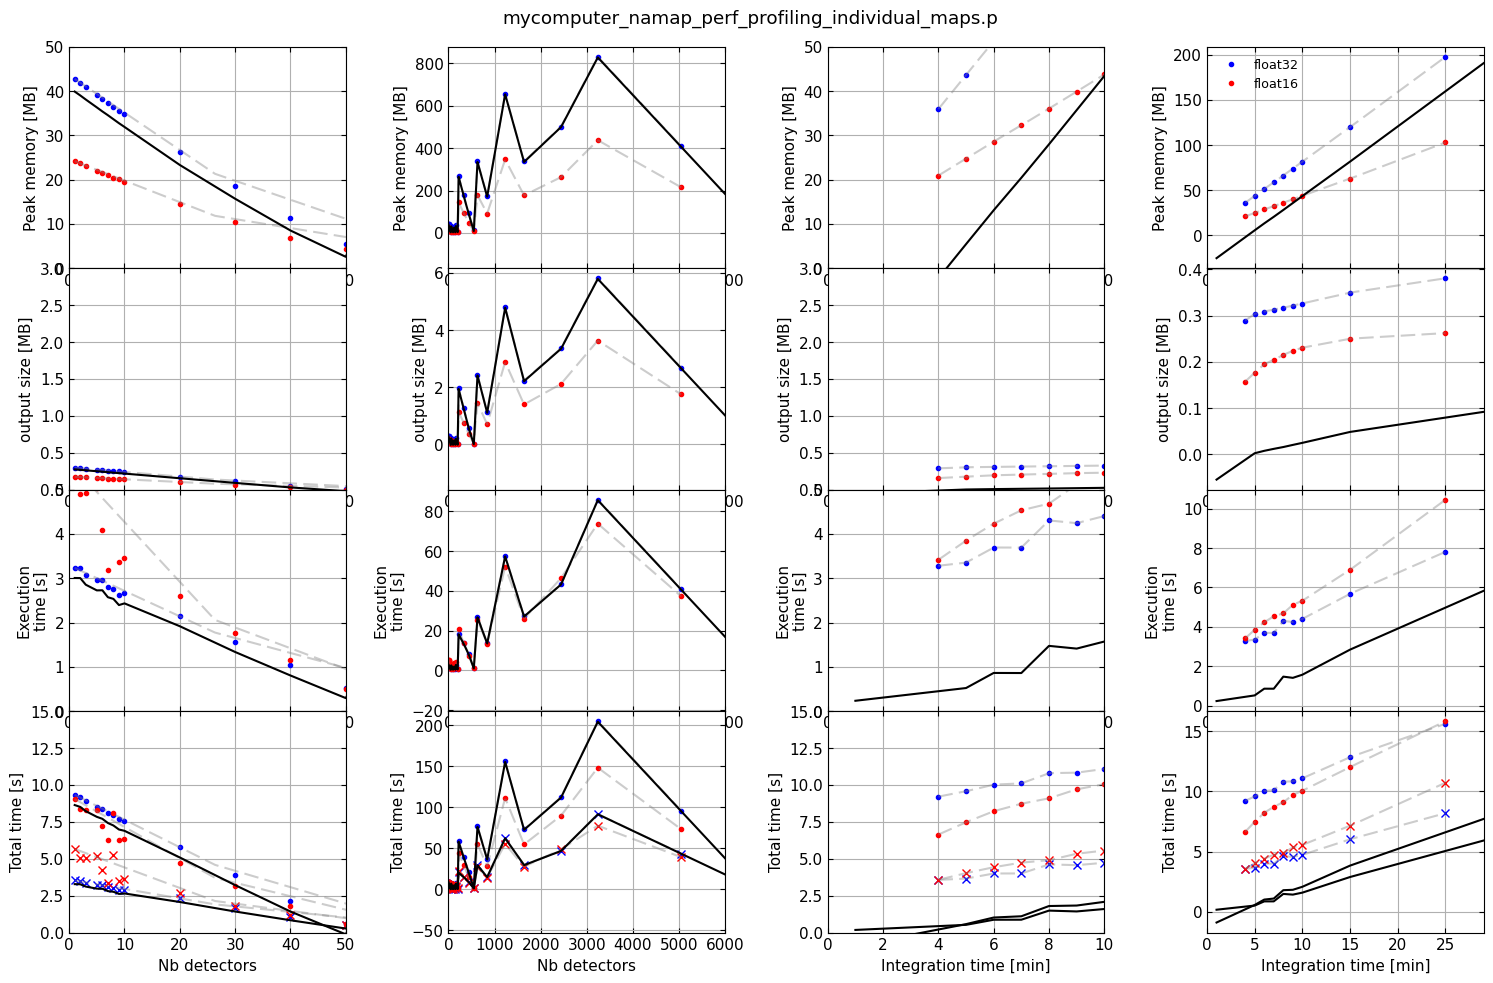

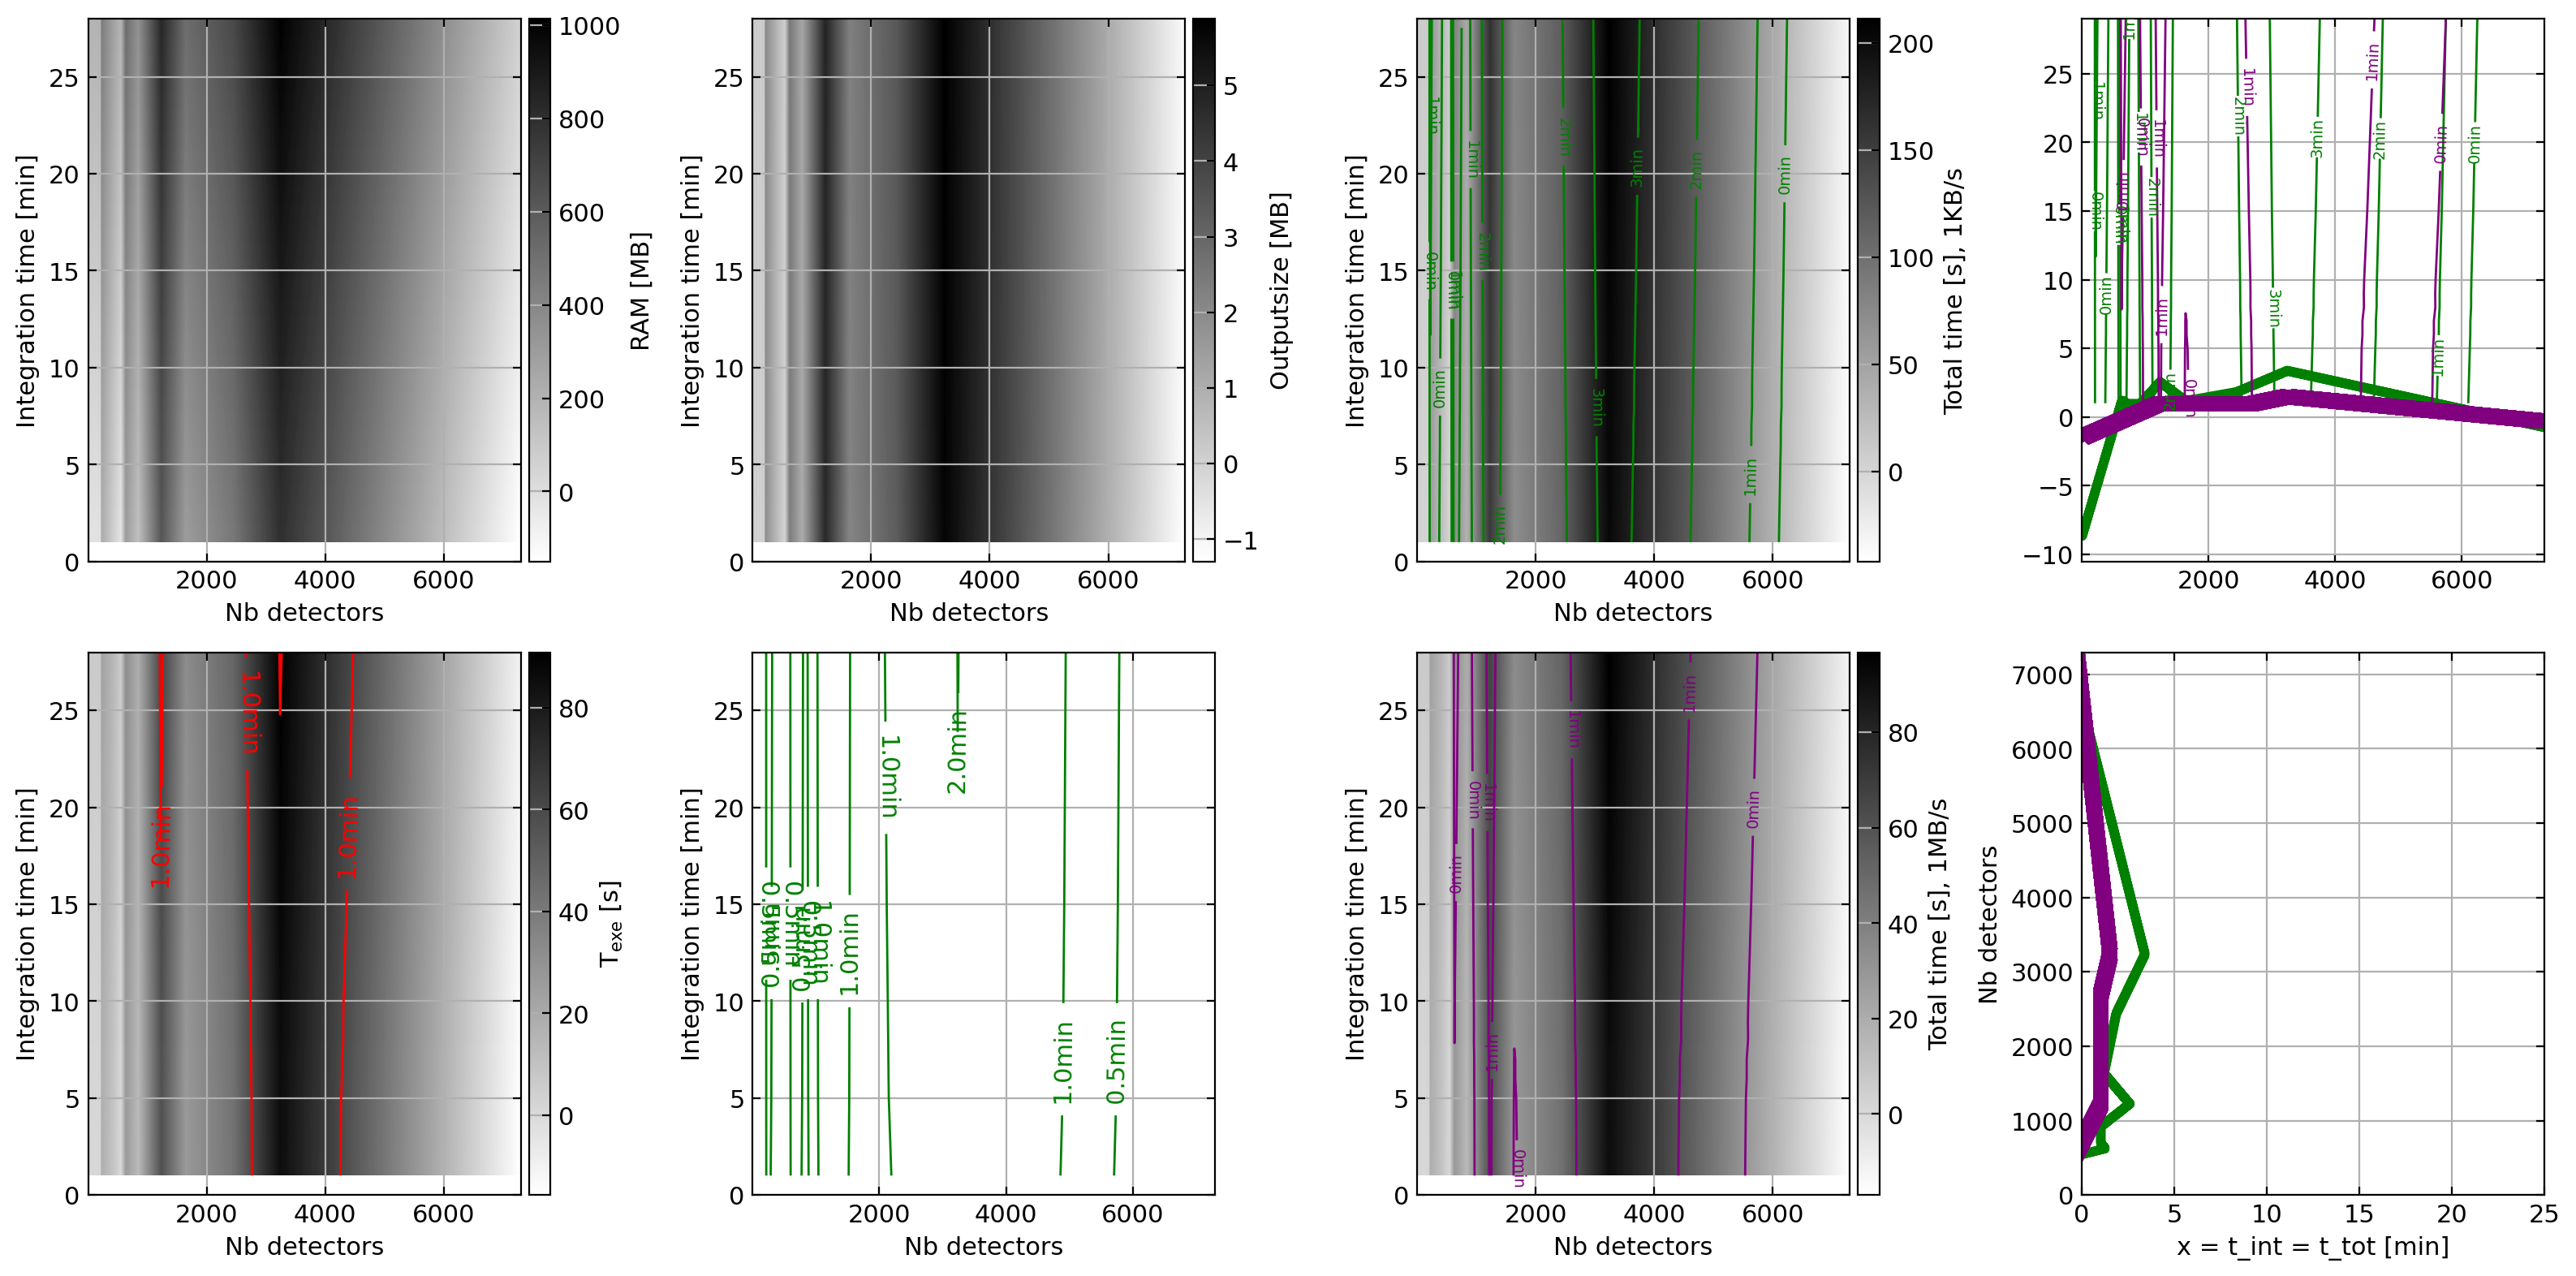

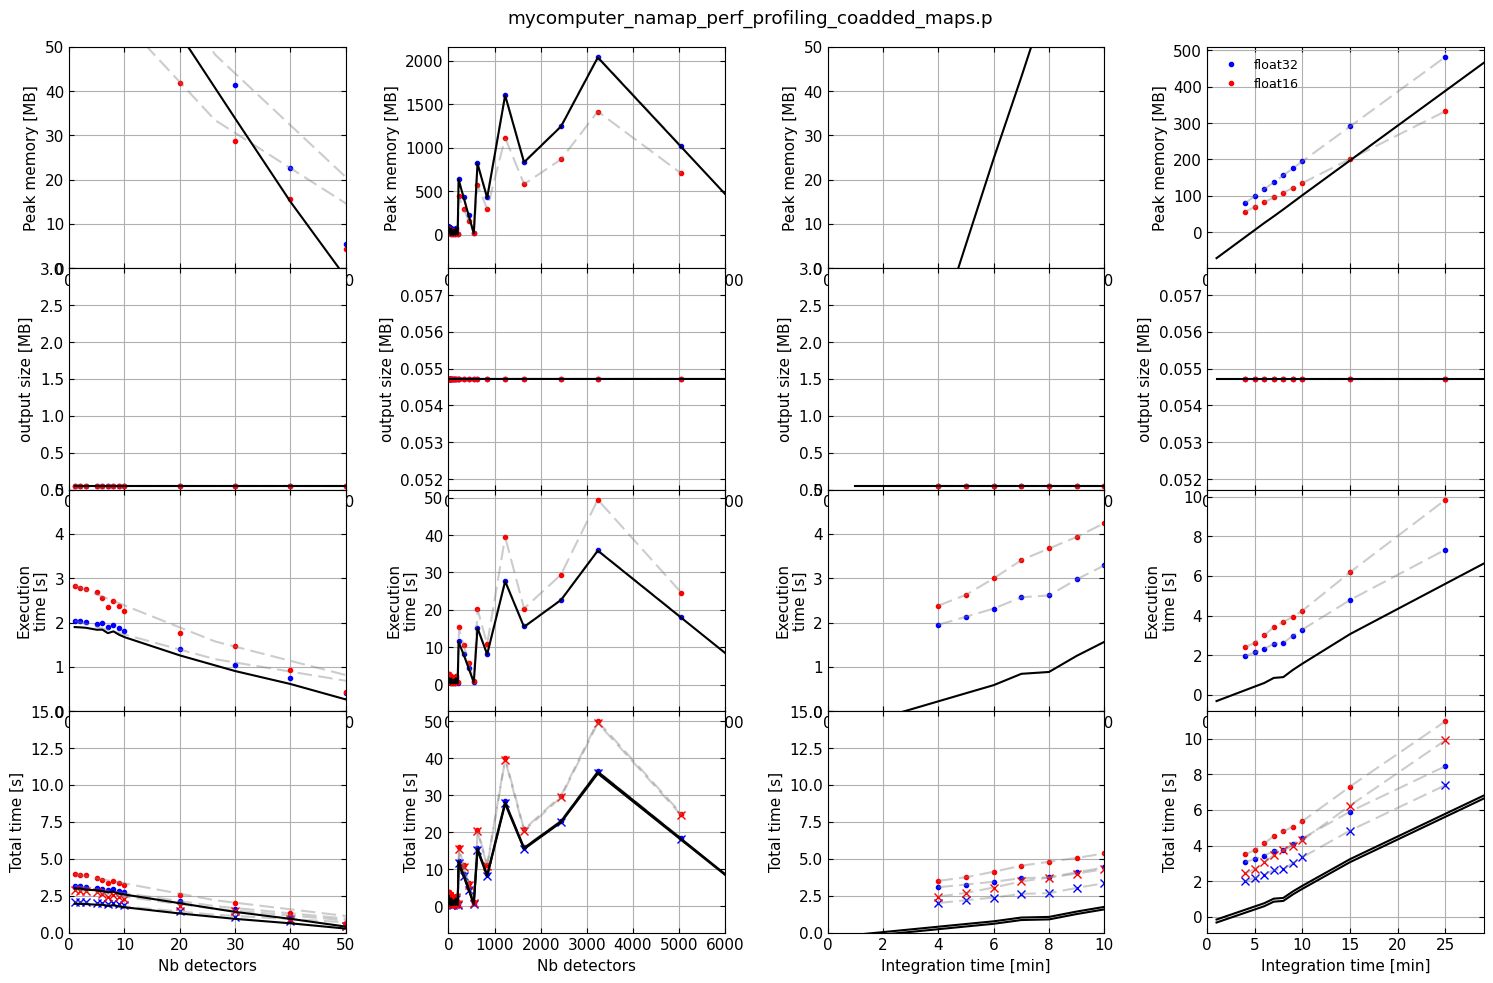

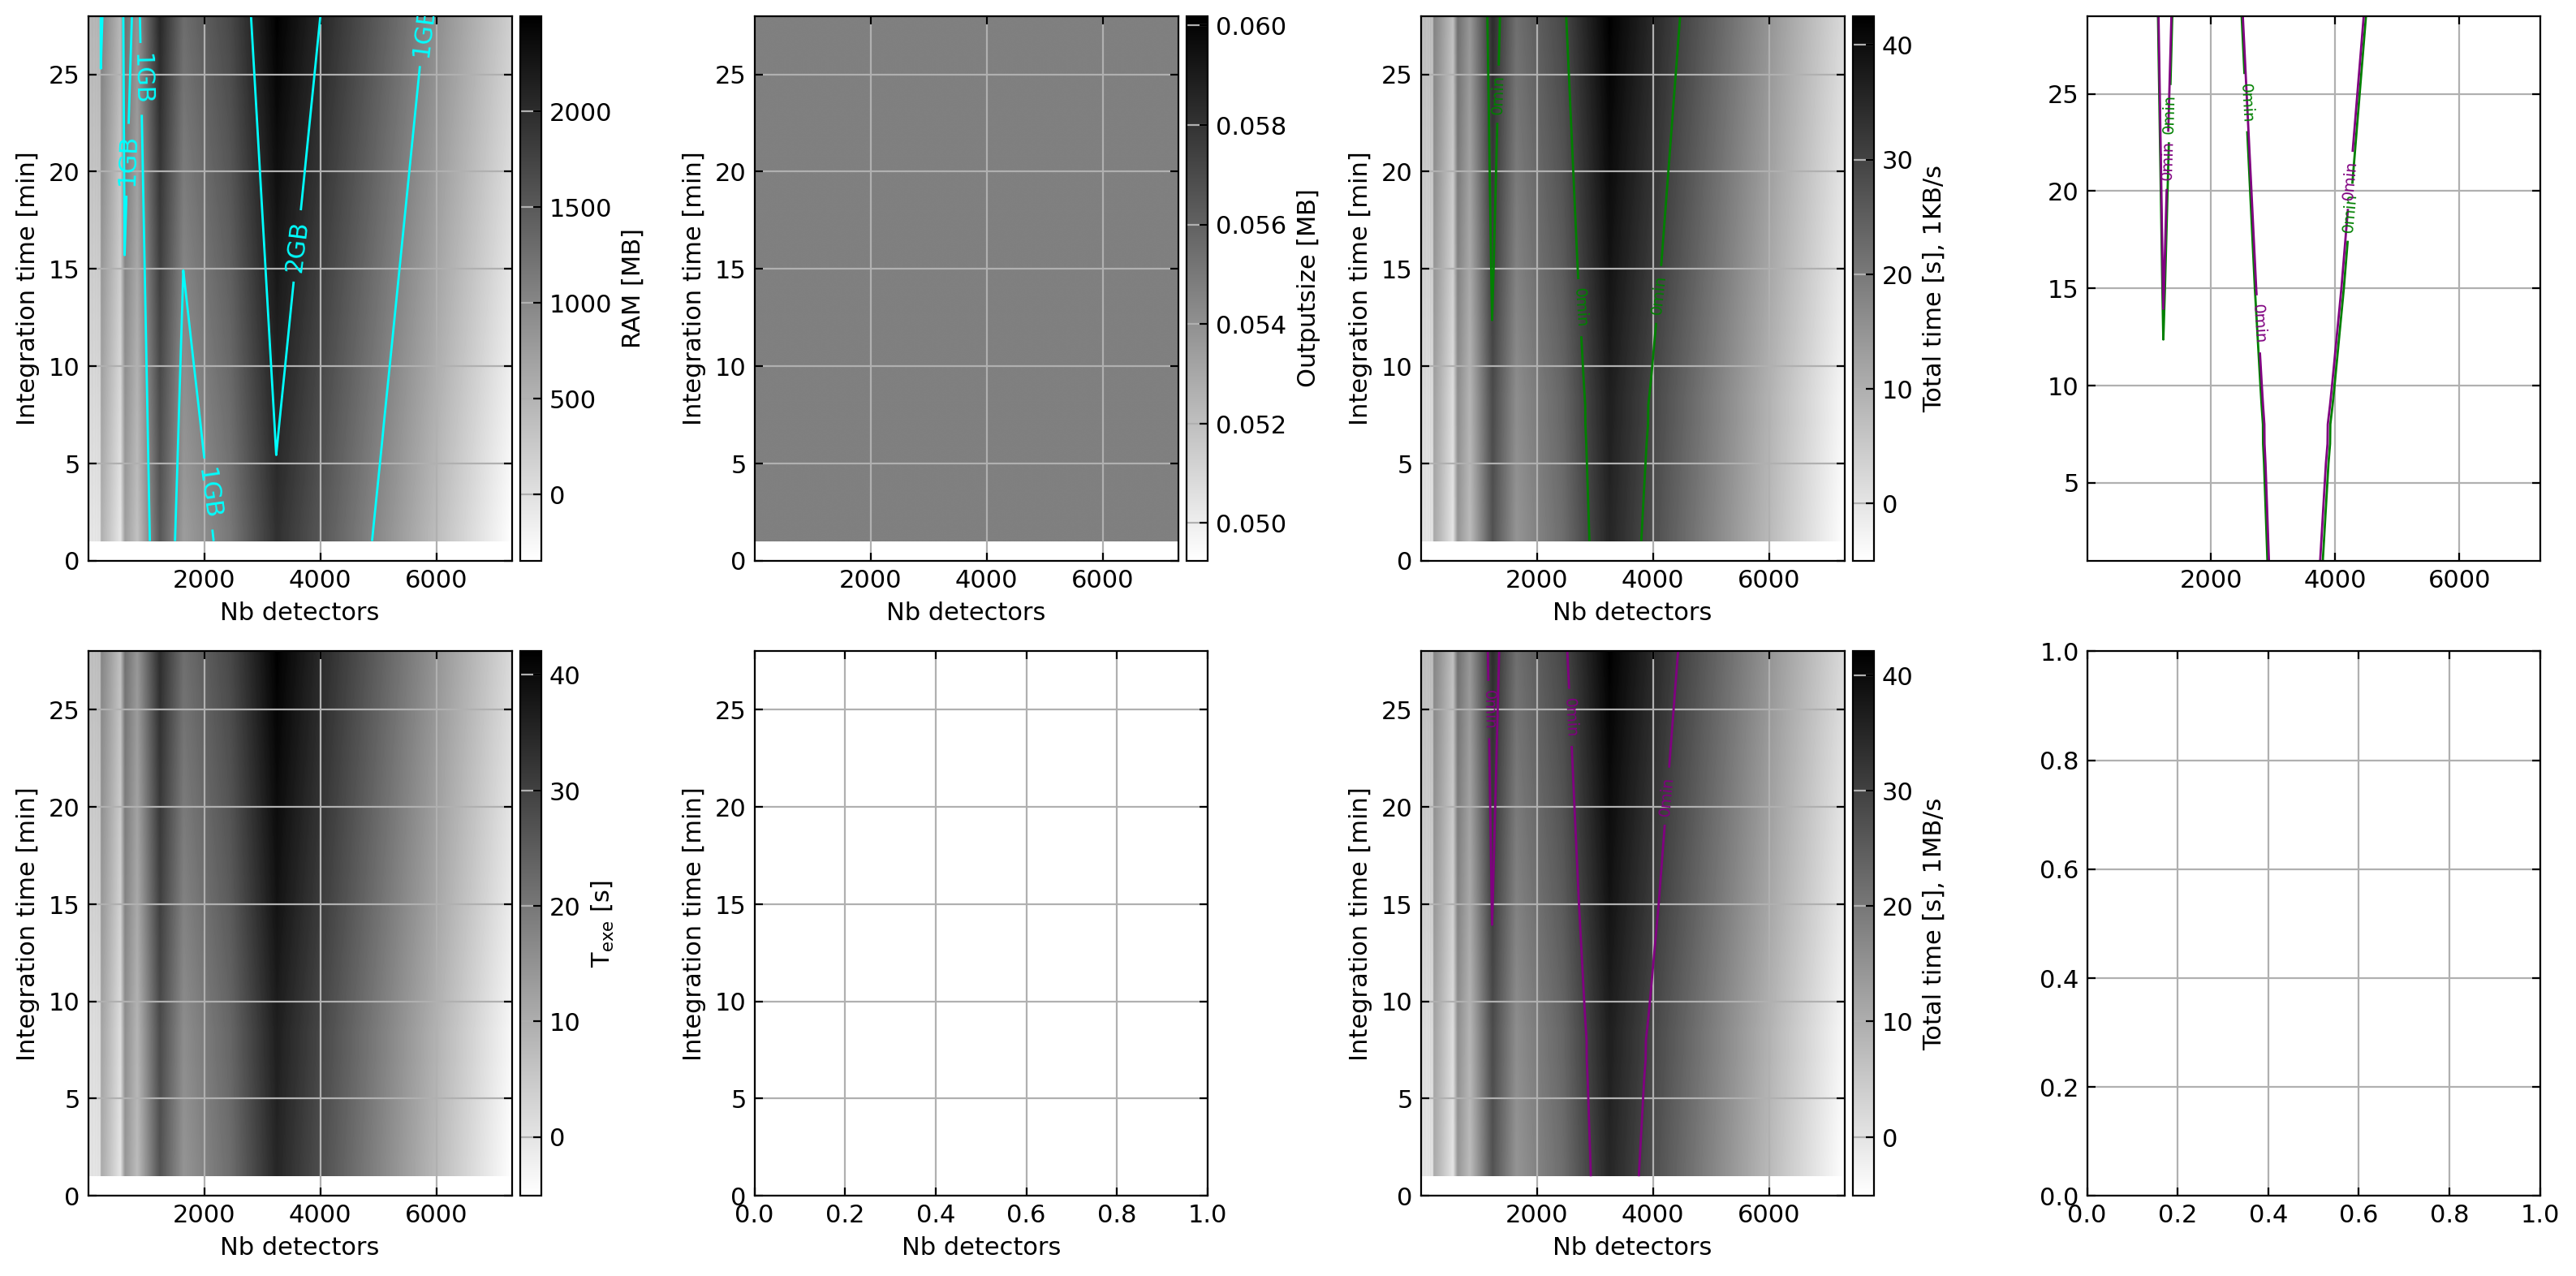

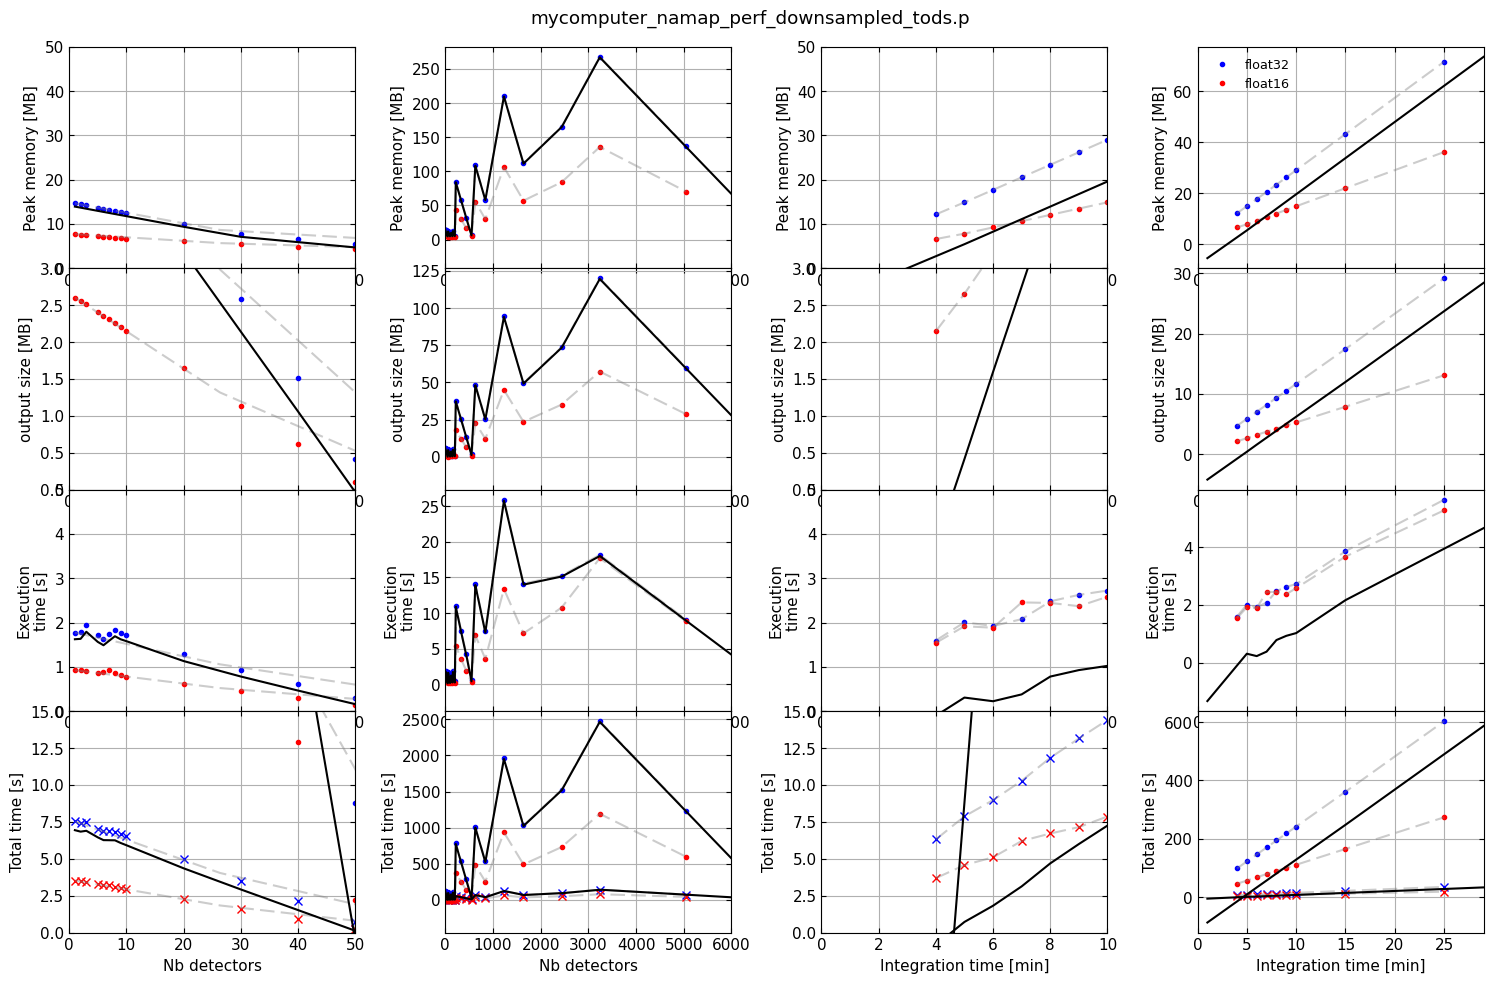

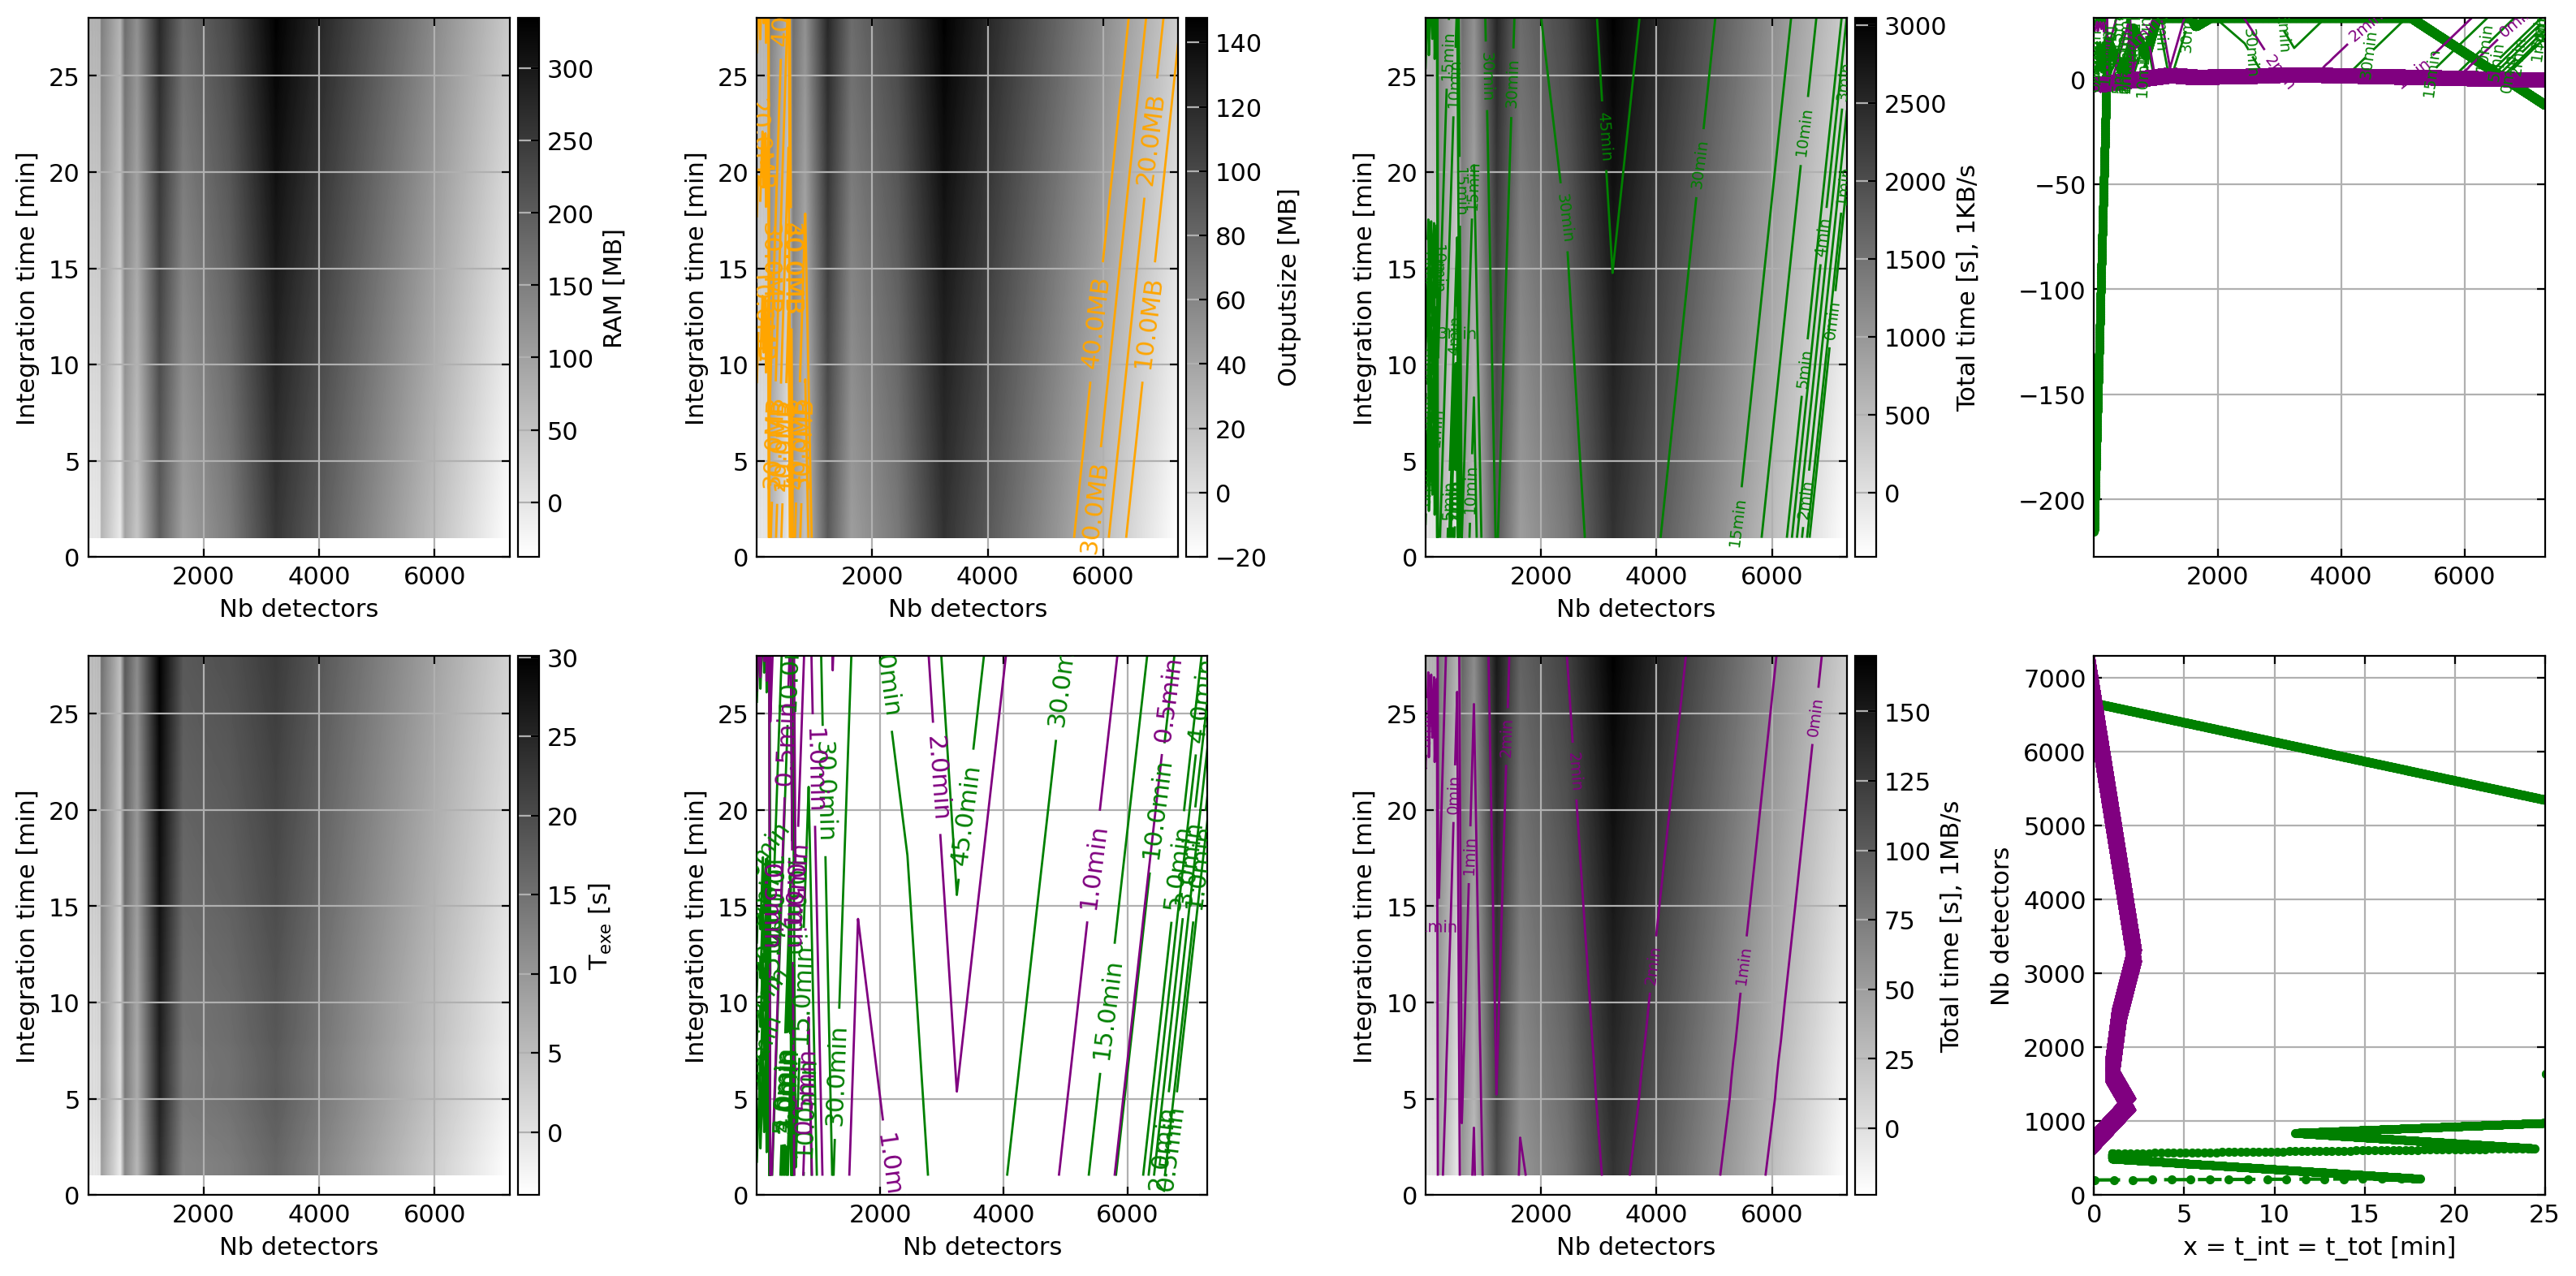

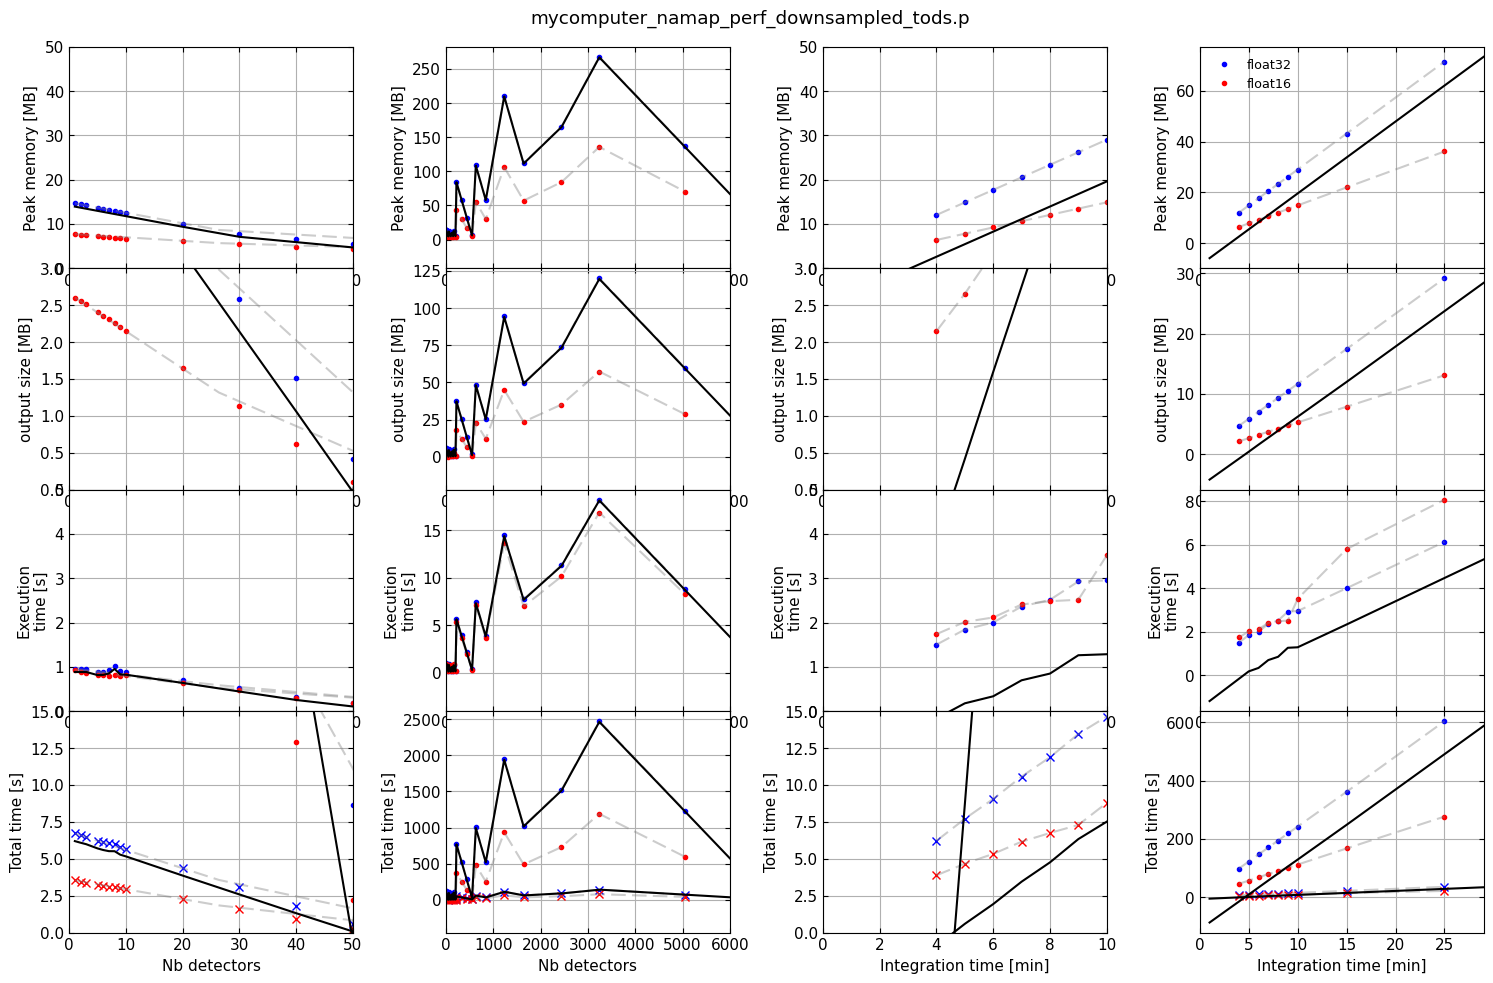

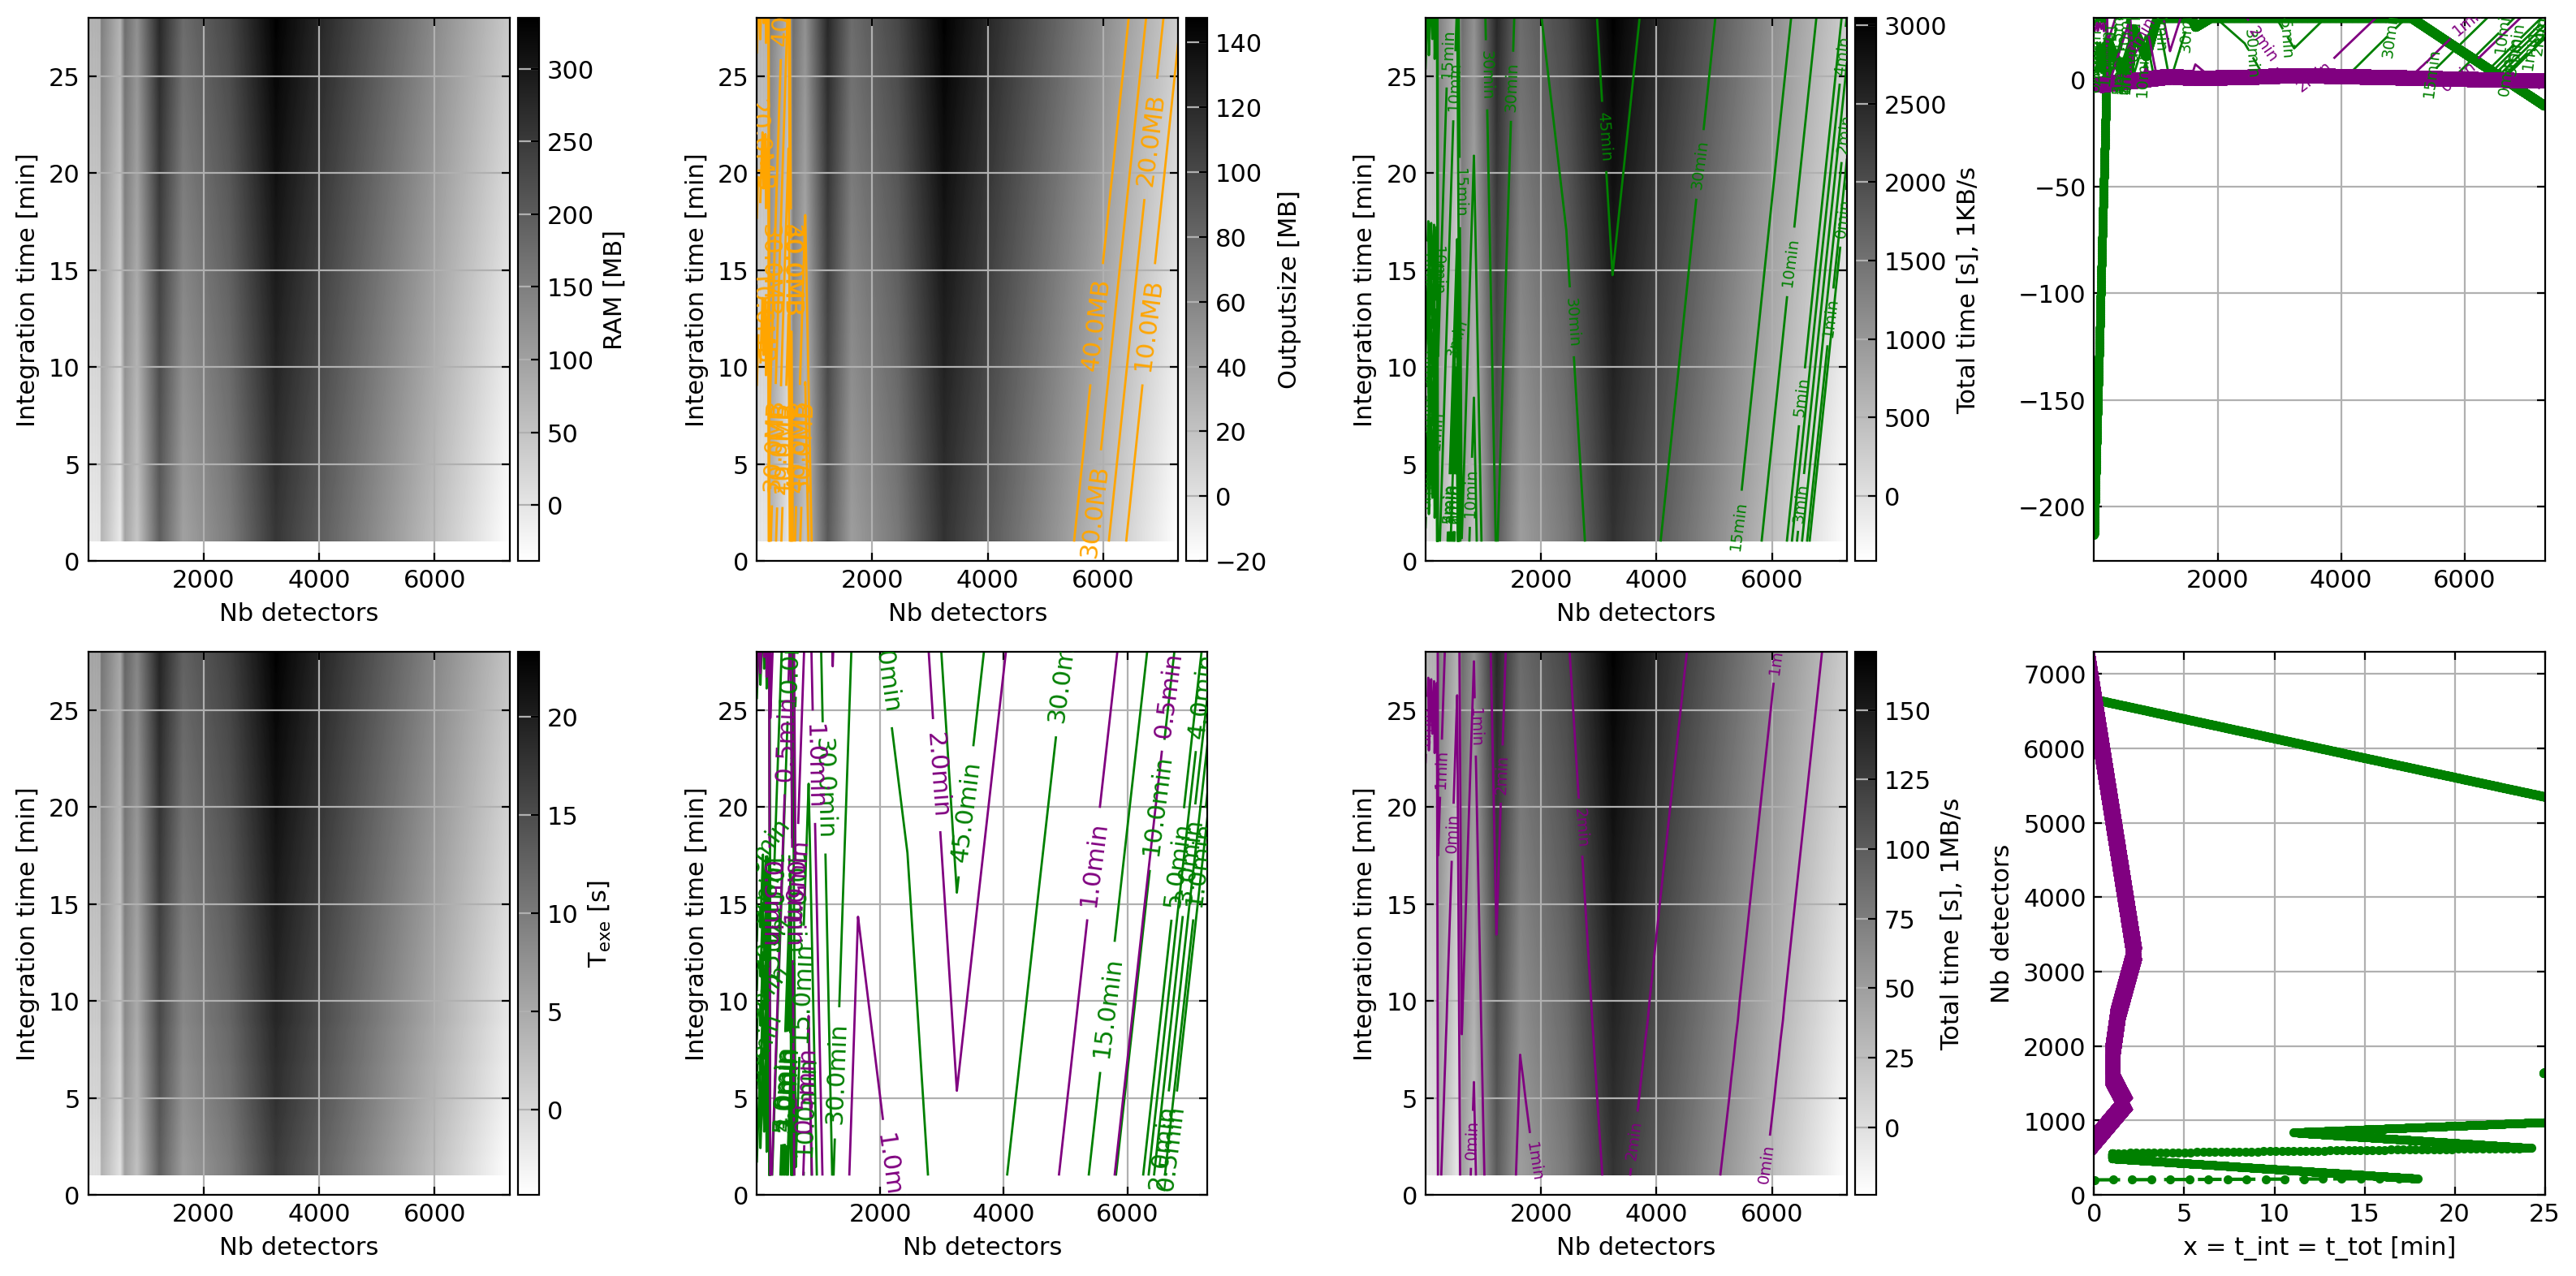

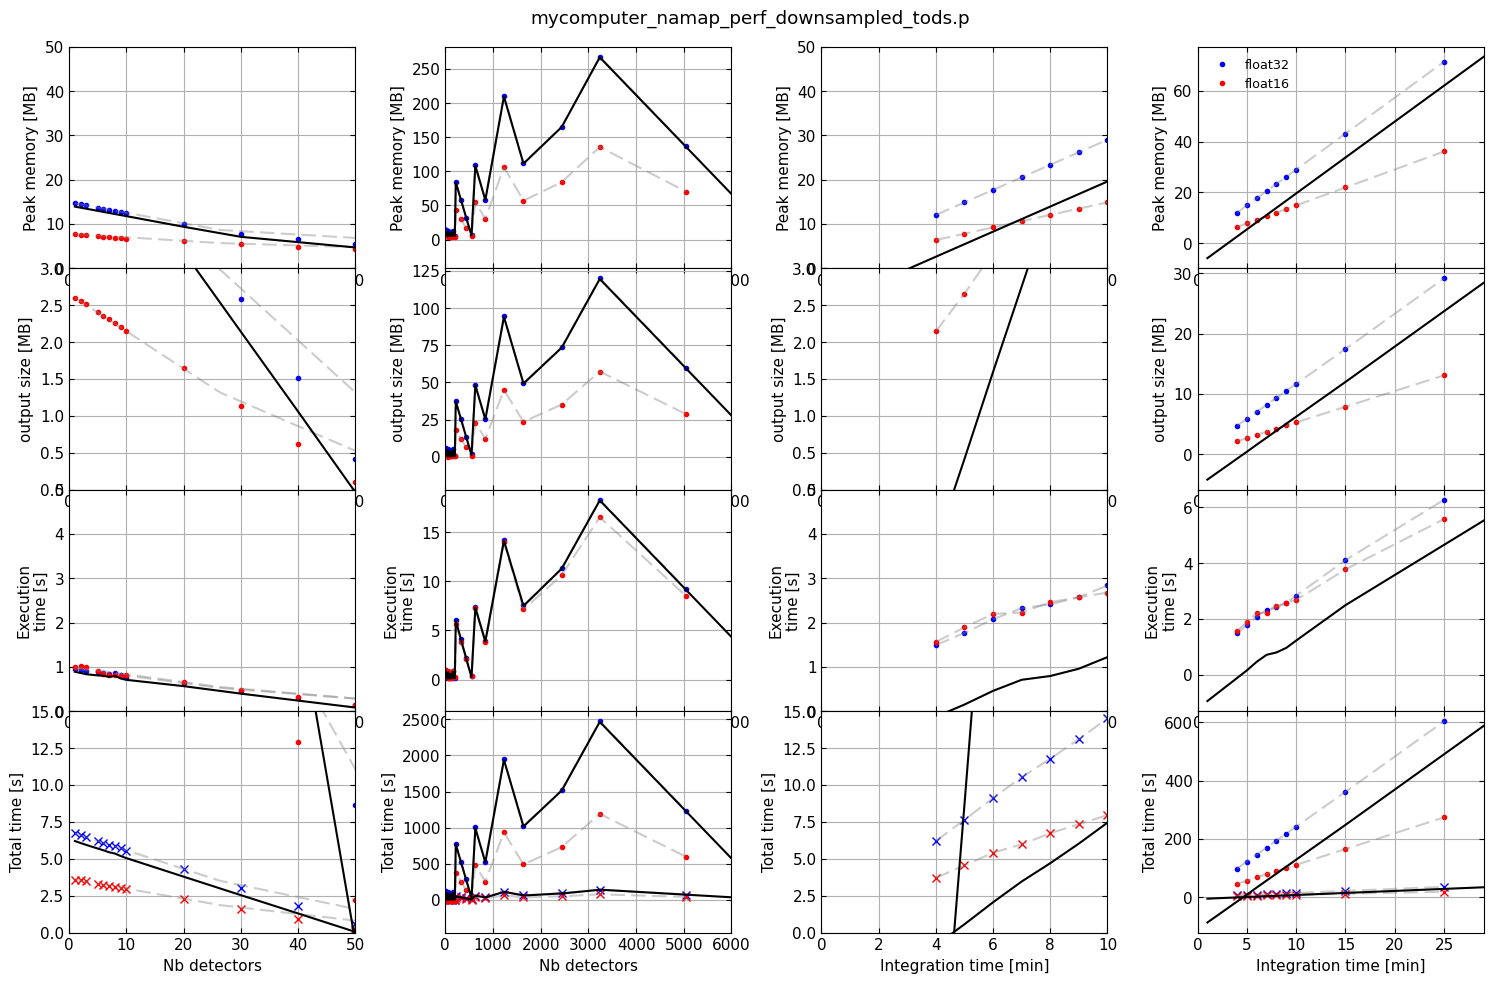

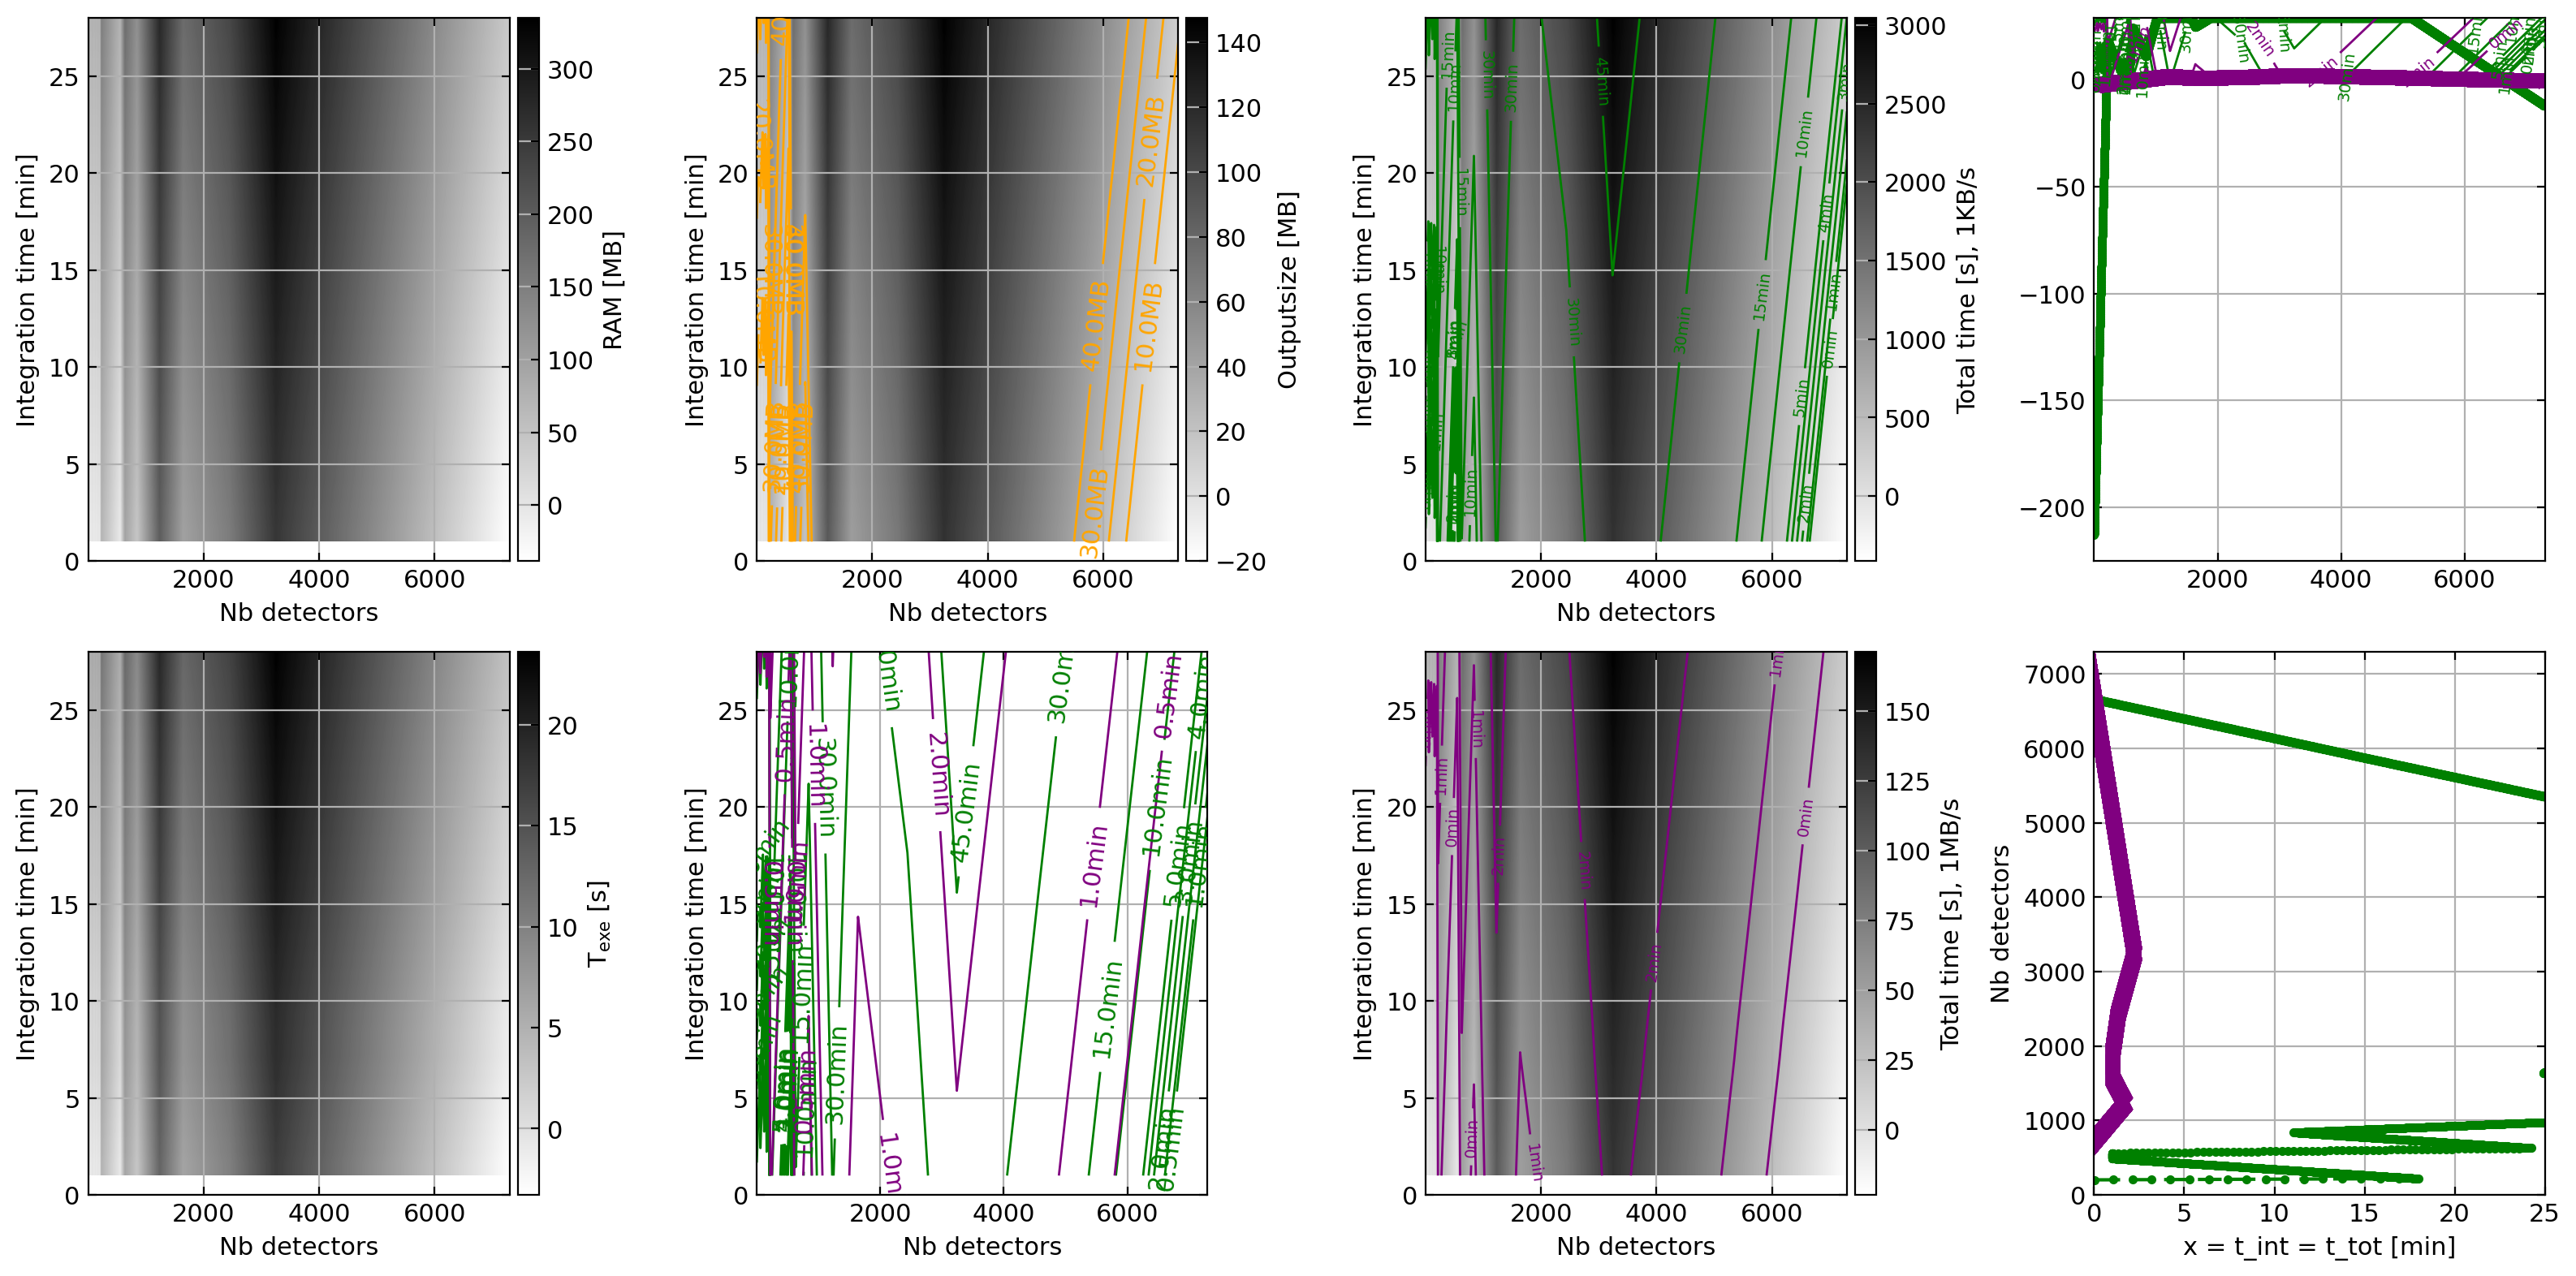

In [2]:
files =         ('namap_perf_profiling_individual_maps.p','namap_perf_profiling_coadded_maps.p','namap_perf_downsampled_tods.p','namap_perf_downsampled_tods.p', 'namap_perf_downsampled_tods.p')# 'namap_perf_raw_tods.p','namap_perf_raw_tods.p' )#,namap_perf_raw_tods.p','namap_perf_downsampled_tods.p', 'namap_perf_profiling_coadded_maps.p','namap_perf_profiling_individual_maps.p')
compressions =  ('individual.fits.gz',                    'coadd.fits' ,                        '',                             '.zip',                           '.hdf5')#'100Hz', 'no_compression'  )#,   '.hdf5','coadd.fits','individual.fits.gz')
label_outputs = ('Individual maps',                       'Coadded map',                        '100Hz TODs',                   'Zip 100Hz TODs',                'hdf5 100Hz TODs')# 'Not synch. 100Hz TODs', 'Not synch. 488Hz TODs')

perfs_params = {}

for ij, (file, map_compression) in enumerate(zip(files, compressions)):

    perfs_params[map_compression] = {}
    
    perfs = pickle.load( open(file, 'rb'))

    fig, axs = plt.subplots(4,4,figsize=(15,10), dpi=100); fig.suptitle(file)

    for i, (key, key2, labelone, lim1, lim2, ref0) in enumerate(zip(('profiling vs nb bands','profiling vs tod time'),( "nb dets","t_int"), ("Nb detectors","Integration time [min]"), (50,10),(6000,29), (N0,T0) ) ):

        perfs_params[map_compression][key] = {}

        axmmin, axbmin, axtmin, axTmin = axs[0,i*2], axs[1,i*2], axs[2,i*2],axs[3,i*2]
        axmmax, axbmax, axtmax, axTmax = axs[0,i*2+1], axs[1,i*2+1], axs[2,i*2+1],axs[3,i*2+1]
        axs[3,i*2].set_xlabel(labelone); axs[3,i*2+1].set_xlabel(labelone)
        axmmin.set_xlim(0,lim1); axbmin.set_xlim(0,lim1); axtmin.set_xlim(0,lim1); axTmin.set_xlim(0,lim1)
        axmmin.set_ylim(0,50); axbmin.set_ylim(0,3); axtmin.set_ylim(0,5); axTmin.set_ylim(0,15)
        axmmax.set_xlim(0,lim2); axbmax.set_xlim(0,lim2); axtmax.set_xlim(0,lim2); axTmax.set_xlim(0,lim2)
        axmmin.set_ylabel('Peak memory [MB]'); axtmin.set_ylabel('Execution\ntime [s]'); axTmin.set_ylabel('Total time [s]'); axbmin.set_ylabel('output size [MB]'); 
        axmmax.set_ylabel('Peak memory [MB]'); axtmax.set_ylabel('Execution\ntime [s]'); axTmax.set_ylabel('Total time [s]'); axbmax.set_ylabel('output size [MB]'); 
    
        for p, (precision, color) in enumerate(zip(( 'float32','float16'),('b','r'))): 

            perfs_params[map_compression][key][precision] = {}
            kind = 'linear'

            #-----------------------------------------------------------------------------------------------------------------------
            x = np.asarray(perfs[key][key2])
            idxref = np.argmin(np.abs(x - ref0))
            y = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]'])
            idx = np.argsort(x)
            u = np.unique(x[idx], return_index=True)[1]
            x, y = x[idx][u], y[idx][u]

            axmmin.plot(x, y, f'.{color}', label= precision)
            axmmax.plot(x, y, f'.{color}', label= precision)
            x_fit = np.linspace(min(x), max(x), 200)
            f1_interp = interp1d(x, y, kind=kind, fill_value='extrapolate')
            axmmax.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
            axmmin.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
            perfs_params[map_compression][key][precision]['peak mem. x'], perfs_params[map_compression][key][precision]['peak mem. y'] = x_fit, f1_interp(x_fit)
            perfs_params[map_compression][key][precision]['peak mem. 0'], perfs_params[map_compression][key][precision][f'peak mem. f'] = y[idxref], f1_interp
            #------------------------------------------------------------------------------------------------------------------------
            y = np.asarray(perfs[key][precision][map_compression]['time [s]'])
            y = y[idx][u]
            axtmax.plot(x, y, f'.{color}')
            axtmin.plot(x, y, f'.{color}')
            f1_interp = interp1d(x, y, kind=kind, fill_value='extrapolate')
            #f1_interp = PchipInterpolator(x, y)  # monotone, no overshoot
            axtmax.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
            axtmin.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
            perfs_params[map_compression][key][precision]['time x'], perfs_params[map_compression][key][precision]['time y'] = x_fit, f1_interp(x_fit)
            perfs_params[map_compression][key][precision]['time 0'], perfs_params[map_compression][key][precision][f'time f'] = y[idxref], f1_interp
            #------------------------------------------------------------------------------------------------------------------------

            #------------------------------------------------------------------------------------------------------------------------
            y = np.asarray(perfs[key][precision][map_compression]['output size [MB]'])
            y = y[idx][u]
            if(map_compression == 'coadd.fits'): 
                y = np.ones(len(y)) * y.max()
            axbmax.plot(x,y, f'.{color}')
            axbmin.plot(x,y, f'.{color}')
            f1_interp = interp1d(x, y, kind=kind, fill_value='extrapolate')
            axbmax.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
            axbmin.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
            perfs_params[map_compression][key][precision][f'output x'], perfs_params[map_compression][key][precision][f'output y']= x_fit, f1_interp(x_fit)
            perfs_params[map_compression][key][precision][f'output 0'], perfs_params[map_compression][key][precision][f'output f'] = y[idxref], f1_interp
            #------------------------------------------------------------------------------------------------------------------------
        
            for t,  (telemetry, marker, label) in enumerate(zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s'))):

                telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
                y =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
                y = y[idx][u]

                axTmax.plot(x,y,f'{marker}{color}', label=label)
                axTmin.plot(x,y,f'{marker}{color}', label=label)
                f1_interp = interp1d(x, y, kind=kind, fill_value='extrapolate')
                axTmax.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
                axTmin.plot(x_fit, f1_interp(x_fit), color='gray', linestyle='--', alpha=0.4)
                perfs_params[map_compression][key][precision][f'{label} x'], perfs_params[map_compression][key][precision][f'{label} y']= x_fit, f1_interp(x_fit)
                perfs_params[map_compression][key][precision][f'{label} 0'], perfs_params[map_compression][key][precision][f'{label} f'] = y[idxref], f1_interp

    def model(f1, f2, T, N, T0, N0, ref):
        offset = f1(T0) + f2(N0) - ref
        model = f1(T) + f2(N) - offset
        return model

    for p, (precision, color) in enumerate(zip(('float32',),('b',))): 

        #---------------------------------------------------------------------
        # unpack parameters
        RAM = 32*1024
        f1 = perfs_params[map_compression]['profiling vs tod time'][precision][f'peak mem. f'] 
        f2 = perfs_params[map_compression]['profiling vs nb bands'][precision][f'peak mem. f'] 
        ref = perfs_params[map_compression]['profiling vs nb bands'][precision][f'peak mem. 0'] 

        ram_grid = model(f1,f2,T_grid, N_grid, T0, N0, ref)
        perfs_params[map_compression]['profiling vs nb bands'][precision]['model RAM'] = ram_grid

        # plot 1D slices
        axs[0,2].plot(YY, ram_grid[:, idxN0], '-k', markersize=1)
        axs[0,3].plot(YY, ram_grid[:, idxN0], '-k', markersize=1)
        axs[0,0].plot(XX[:], ram_grid[idxT0, :], '-k', markersize=1)
        axs[0,1].plot(XX[:], ram_grid[idxT0, :], '-k', markersize=1)
        #---------------------------------------------------------------------

        #--------------------------------------------------------------------
        f1 = perfs_params[map_compression]['profiling vs tod time'][precision][f'time f'] 
        f2 = perfs_params[map_compression]['profiling vs nb bands'][precision][f'time f'] 
        ref = perfs_params[map_compression]['profiling vs nb bands'][precision][f'time 0'] 

        Texe_grid = model(f1,f2,T_grid, N_grid, T0, N0, ref)
        perfs_params[map_compression]['profiling vs nb bands'][precision]['model Texe'] = Texe_grid

        # plot 1D slices
        axs[2,2].plot(YY, Texe_grid[:, idxN0], '-k', markersize=1)
        axs[2,3].plot(YY, Texe_grid[:, idxN0], '-k', markersize=1)
        axs[2,0].plot(XX[:], Texe_grid[idxT0, :], '-k', markersize=1)
        axs[2,1].plot(XX[:], Texe_grid[idxT0, :], '-k', markersize=1)
        #--------------------------------------------------------------------------
        #--------------------------------------------------------------------
        f1 = perfs_params[map_compression]['profiling vs tod time'][precision][f'output f'] 
        f2 = perfs_params[map_compression]['profiling vs nb bands'][precision][f'output f'] 
        ref = perfs_params[map_compression]['profiling vs nb bands'][precision][f'output 0'] 

        output_grid = model(f1,f2,T_grid, N_grid, T0, N0, ref)
        perfs_params[map_compression]['profiling vs nb bands'][precision]['model output'] = output_grid

        # plot 1D slices
        axs[1,2].plot(YY, output_grid[:, idxN0], '-k', markersize=1)
        axs[1,3].plot(YY, output_grid[:, idxN0], '-k', markersize=1)
        axs[1,0].plot(XX[:], output_grid[idxT0, :], '-k', markersize=1)
        axs[1,1].plot(XX[:], output_grid[idxT0, :], '-k', markersize=1)
        #--------------------------------------------------------------------------
        
        for t,  (telemetry, marker, label, ct) in enumerate(zip((0.048828125,1 ), ('.','x'), ('1KB/s', '1MB/s'), ('g', 'purple'))):
            
            f1 = perfs_params[map_compression]['profiling vs tod time'][precision][f'{label} f'] 
            f2 = perfs_params[map_compression]['profiling vs nb bands'][precision][f'{label} f'] 
            ref = perfs_params[map_compression]['profiling vs nb bands'][precision][f'{label} 0'] 
            Texe_grid = model(f1,f2,T_grid, N_grid, T0, N0, ref)
            perfs_params[map_compression]['profiling vs nb bands'][precision][f'model {label} Ttot'] = Texe_grid

            # plot 1D slices
            axs[3,2].plot(YY, Texe_grid[:, idxN0], '-k', markersize=1)
            axs[3,3].plot(YY, Texe_grid[:, idxN0], '-k', markersize=1)
            axs[3,0].plot(XX[:], Texe_grid[idxT0, :], '-k', markersize=1)
            axs[3,1].plot(XX[:], Texe_grid[idxT0, :], '-k', markersize=1)
            #perfs[label]['Ttot map'] = Ttot_grid
            
    patchs = []
    patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
    patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
    axmmax.legend(handles=patchs)
    axmmax.legend()
    
    patchs = []
    patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
    patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
    #axTmax.legend(handles=patchs)
    '''
    def f_to_z(x): return x/ (16 *1024)*100
    secax = axmmax.secondary_yaxis("right", functions=(f_to_z,f_to_z))
    secax.set_ylabel(f'% RAM')

    def f_to_z(x): return x/0.048828125
    secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
    secax.set_ylabel(f'T download [s]\npessimist')
    '''
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    with open(file, 'wb') as f: pickle.dump(perfs, f)

    #####################################33
    figmaps, axsmaps = plt.subplots(2,4,figsize=(16,8), dpi=200)

    for l1 in range(2):
        for l2 in range(3):
            axsmaps[l1,l2].set_ylabel("Integration time [min]")
            axsmaps[l1,l2].set_xlabel("Nb detectors")
            axsmaps[l1,l2].set_ylim(0,28)

    for p, (precision, color) in enumerate(zip(('float32', ),('b',))): 

        ax = axsmaps[0,0]
        ram_grid = perfs_params[map_compression]['profiling vs nb bands'][precision]['model RAM'] 
        im = ax.imshow( ram_grid, cmap='binary', aspect='auto', extent=[XX.min(), XX.max(), YY.min(), YY.max()],origin='lower')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('RAM [MB]')
        CS = ax.contour(N_grid, T_grid,ram_grid, levels=(1024, 2048, 3072, 4096, 5120, 6144), colors='cyan', linewidths=1.0,linestyle = ':',)
        ax.clabel(CS, inline=True, fmt=lambda v: f"{v/1024:.0f}GB", colors='cyan')

        ax = axsmaps[1,0]
        Texe_grid = perfs_params[map_compression]['profiling vs nb bands'][precision]['model Texe'] 
        im = ax.imshow( Texe_grid, cmap='binary', aspect='auto', extent=[XX.min(), XX.max(), YY.min(), YY.max()],origin='lower')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('$\\rm T_{exe}$ [s]')
        CS = ax.contour(N_grid, T_grid,Texe_grid, levels=np.asarray((1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5,5))*60, colors='r', linewidths=1.0,linestyle = ':',)
        ax.clabel(CS, inline=True, fmt=lambda v: f"{v/60:.1f}min", colors='r')

        ax = axsmaps[0,1]
        output_grid = perfs_params[map_compression]['profiling vs nb bands'][precision]['model output'] 
        im = ax.imshow( output_grid, cmap='binary', aspect='auto', extent=[XX.min(), XX.max(), YY.min(), YY.max()],origin='lower')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('$\\rm Output size $ [MB]')
        CS = ax.contour(N_grid, T_grid, output_grid, levels=np.asarray((10,20,30,40)), colors='orange', linewidths=1.0,linestyle = ':',)
        ax.clabel(CS, inline=True, fmt=lambda v: f"{v:.1f}MB", colors='orange')

        for t,  (telemetry, marker, label, ct) in enumerate(zip((0.048828125,1 ), ('.','x'), ('1KB/s', '1MB/s'), ('g', 'purple'))):
            f1 = perfs_params[map_compression]['profiling vs tod time'][precision][f'{label} f'] 
            f2 = perfs_params[map_compression]['profiling vs nb bands'][precision][f'{label} f'] 
            ref = perfs_params[map_compression]['profiling vs nb bands'][precision][f'{label} 0'] 

            Ttot_grid = perfs_params[map_compression]['profiling vs nb bands'][precision][f'model {label} Ttot'] 
            D = Ttot_grid-T_grid*60
            #Tdownload_grid = Ttot_grid - Texe_grid
            ax = axsmaps[t,2]
            im = ax.imshow( Ttot_grid, cmap='binary', aspect='auto', extent=[XX.min(), XX.max(), YY.min(), YY.max()],origin='lower')
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label(f'Total time [s], {label}')
            levels = np.asarray((0.5,1,2,3,4,5,10,15,30,45))*60
            CS = ax.contour(N_grid, T_grid, Ttot_grid, levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
            ax.clabel(CS, inline=True, fmt=lambda v: f"{v/60:.0f}min", fontsize=7, colors=ct)
            #ax.contour(N_grid, T_grid, D, levels=[0], colors=[ct], linestyles=[':'])

            ax = axsmaps[0,3]
            ax.contour(N_grid, T_grid, D, levels=[0], colors=[ct], linestyles=[':'])
            CS = ax.contour(N_grid, T_grid, Ttot_grid, levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
            ax.clabel(CS, inline=True, fmt=lambda v: f"{v/60:.0f}min", fontsize=7, colors=ct)
            
            # -------------------------
            # Slice-by-slice zero crossing in physical N units
            # -------------------------

            # ---------------------------------------
            # Extract D = 0 contour directly
            # ------------------------= Texe_grid---------------
            
            CS_zero = ax.contour(N_grid, T_grid, D, levels=[0], colors=[ct], linestyles=[':'])

            # Get contour vertices (there can be multiple disconnected pieces)
            paths = CS_zero.collections[0].get_paths()

            if not paths:  # skip if no contour paths for this level
                continue

            # Concatenate all contour segments
            vertices = np.vstack([p.vertices for p in paths])
            
            # Separate coordinates
            x_zero = vertices[:, 0]   # N values
            y_zero = vertices[:, 1]   # T values

            # Sort by N for interpolation stability
            sort_idx = np.argsort(x_zero)
            x_zero = x_zero[sort_idx]
            y_zero = y_zero[sort_idx]

            # Interpolation (choose kind='linear' or 'cubic')
            f1_interp = interp1d(x_zero, y_zero, kind=kind, fill_value='extrapolate')

            # ---------------------------------------
            # Plot fitted curve
            # ---------------------------------------
            ax.plot(XX, f1_interp(XX), c=ct, marker=marker, ls='--')
            axsmaps[1,3].plot(f1_interp(XX), XX, c=ct, marker=marker, ls='--')

            perfs_params[map_compression]['profiling vs tod time'][precision][f'x Ttot=t, {label}'] = XX
            perfs_params[map_compression]['profiling vs tod time'][precision][f'y Ttot=t, {label}'] = f1_interp(XX)

            '''
            def solve_curve(f1, f2, T_values, T0, N0, ref):

                offset = f1(T0) + f2(N0) - ref
                target = T_values - f1(T_values) + offset
                xprime = f2.x
                yprime = f2.y
                # Handle monotonicity automatically
                if np.all(np.diff(yprime) > 0):
                    N = np.interp(target, yprime, xprime)
                else:
                    N = np.interp(target, yprime[::-1], xprime[::-1])
                return N
            
            f1 = perfs_params['profiling vs tod time'][precision][f'{label} f'] 
            f2 = perfs_params['profiling vs nb bands'][precision][f'{label} f'] 
            ref = perfs_params['profiling vs nb bands'][precision][f'{label} 0'] 
            N_sol = solve_curve(f1, f2, YY*60, T0, N0, ref)
            print(N_sol)
            
            axsmaps[0,3].plot(N_sol, YY, c='k', marker=marker, ls=':')
            axsmaps[1,3].plot(YY, N_sol, c='k', marker=marker, ls=':')
            '''
            
            axsmaps[1,3].set_xlabel("x = t_int = t_tot [min]")
            axsmaps[1,3].set_ylabel("Nb detectors")
            axsmaps[1,3].set_xlim(0,25)
            axsmaps[1,3].set_ylim(0,64*(51+63))
            #-----------------------------------

            ax = axsmaps[1,1]
            telemetry_grid = output_grid / telemetry
            CS = ax.contour(N_grid, T_grid,telemetry_grid, levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
            ax.clabel(CS, inline=True, fmt=lambda v: f"{v/60:.1f}min", colors=ct)
            
    figmaps.tight_layout()
    with open(file, 'wb') as f: pickle.dump(perfs, f)


/tmp/ipykernel_129982/3096924961.py:34: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = AX.contour(perfs_params[map_compression]['profiling vs nb bands'][precision][f'model {label} Ttot'],
/tmp/ipykernel_129982/3096924961.py:50: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs.set_ylim(0,60)
/tmp/ipykernel_129982/3096924961.py:58: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axa.set_ylim(0,60)
/tmp/ipykernel_129982/3096924961.py:73: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axc.set_ylim(0,60)


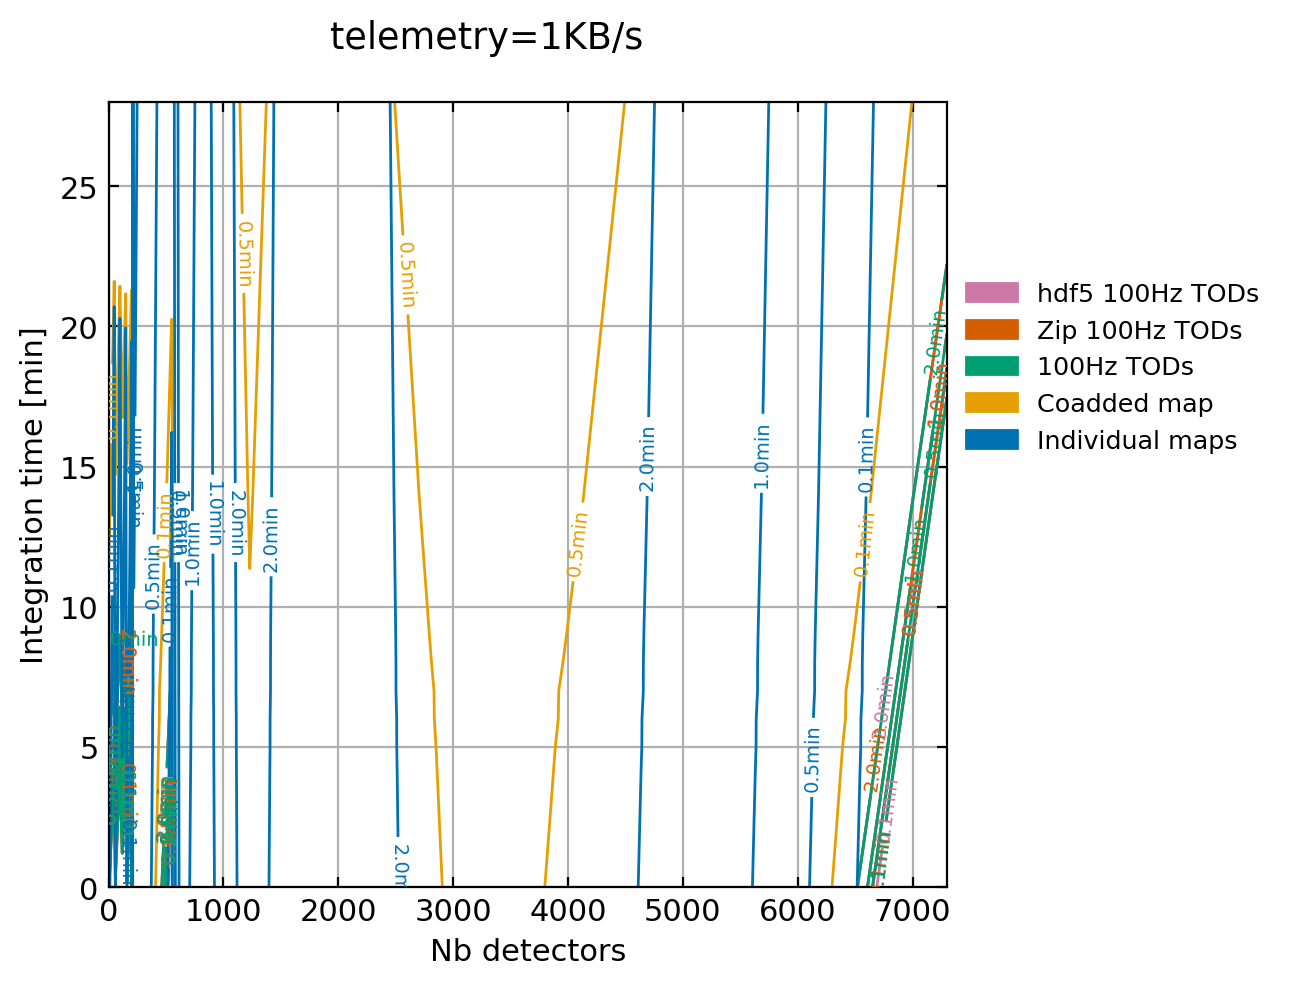

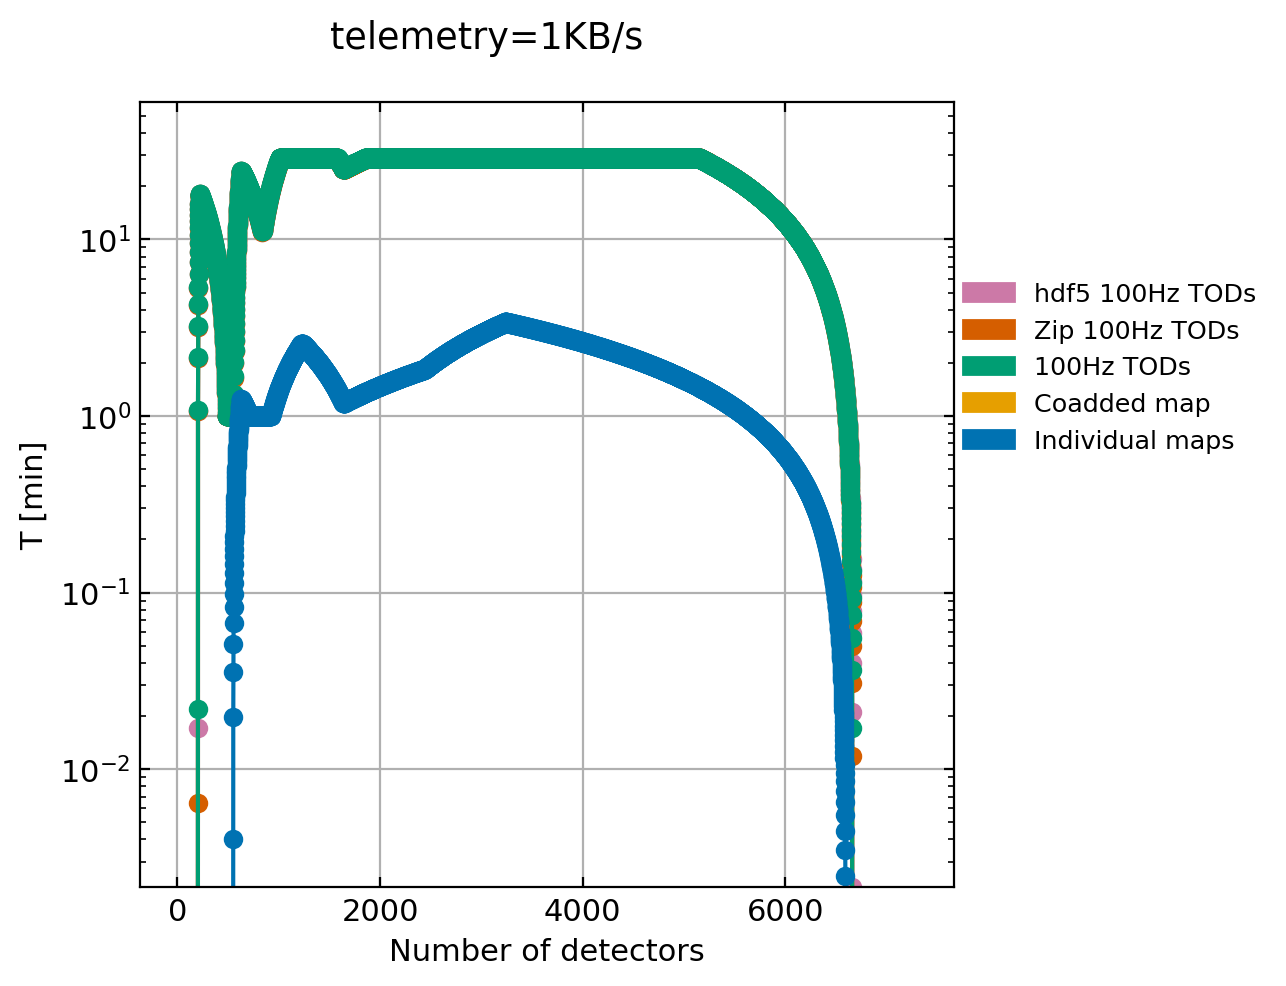

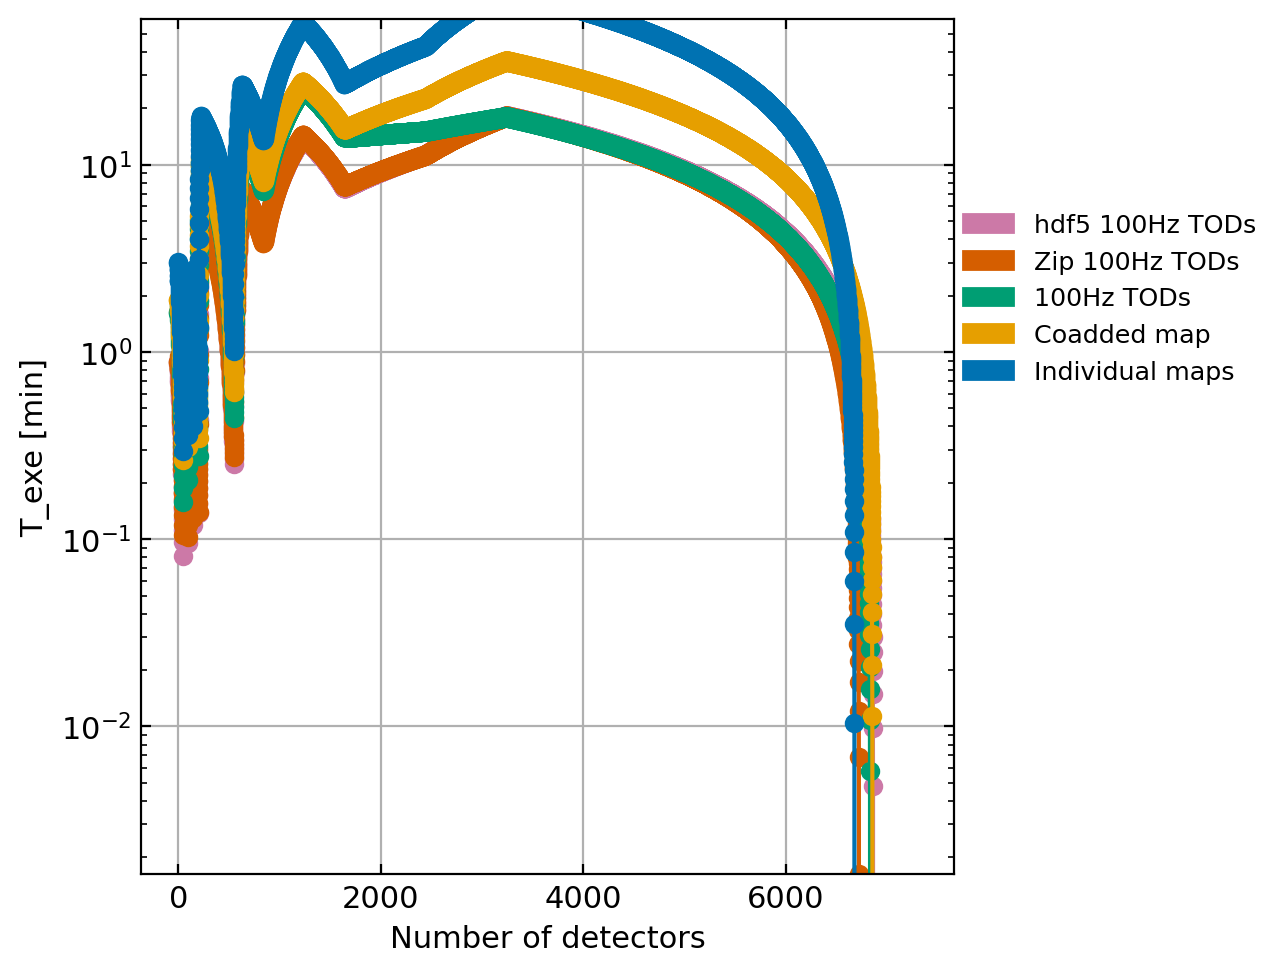

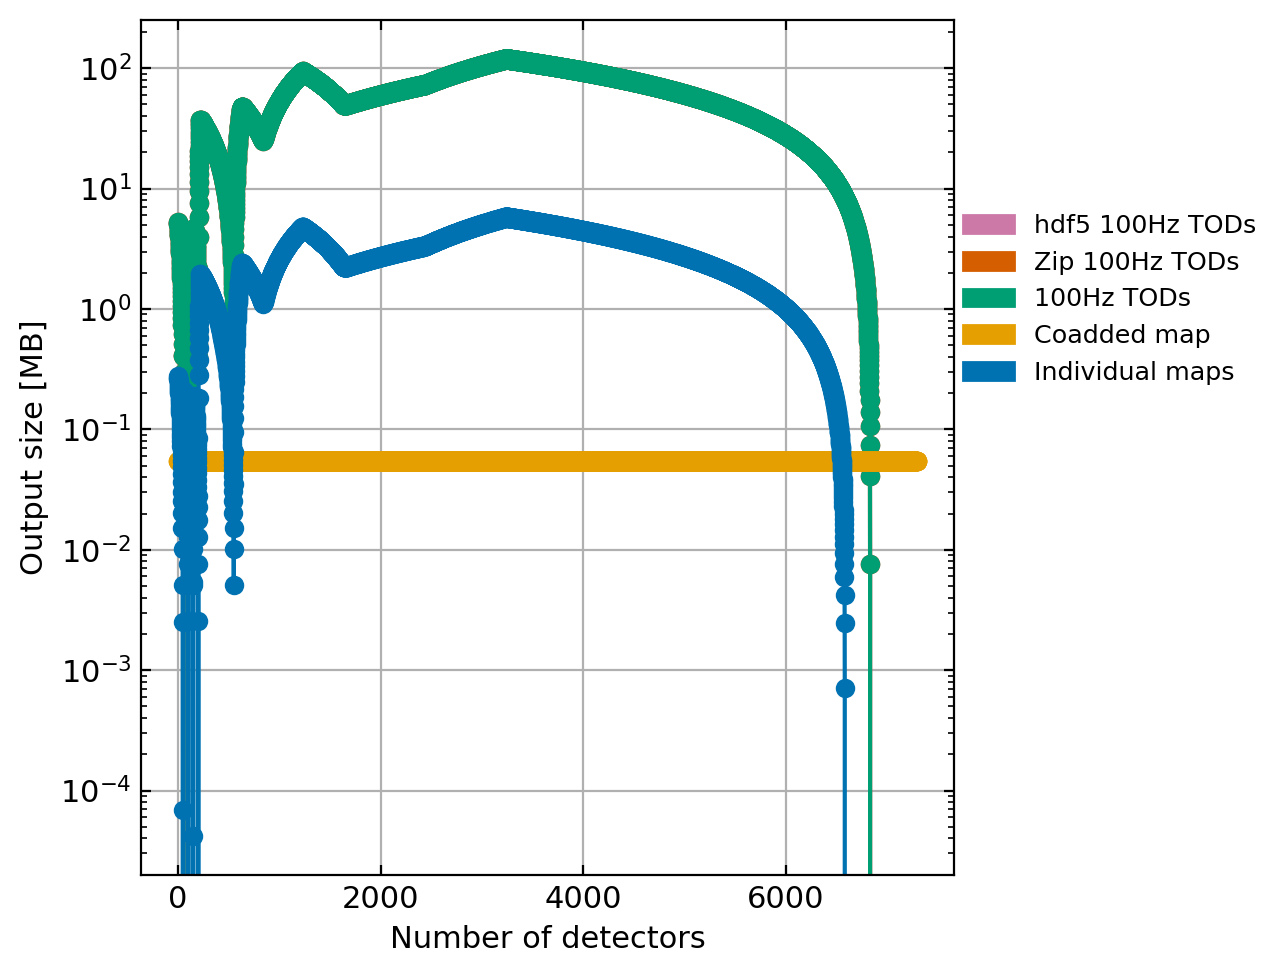

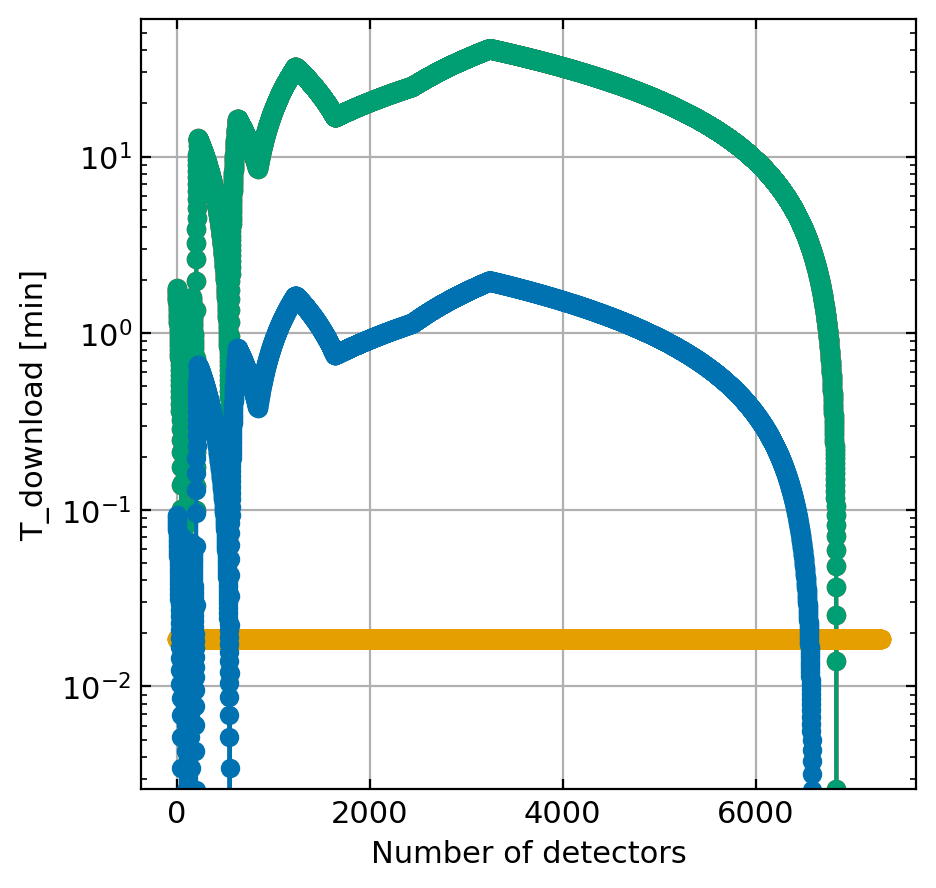

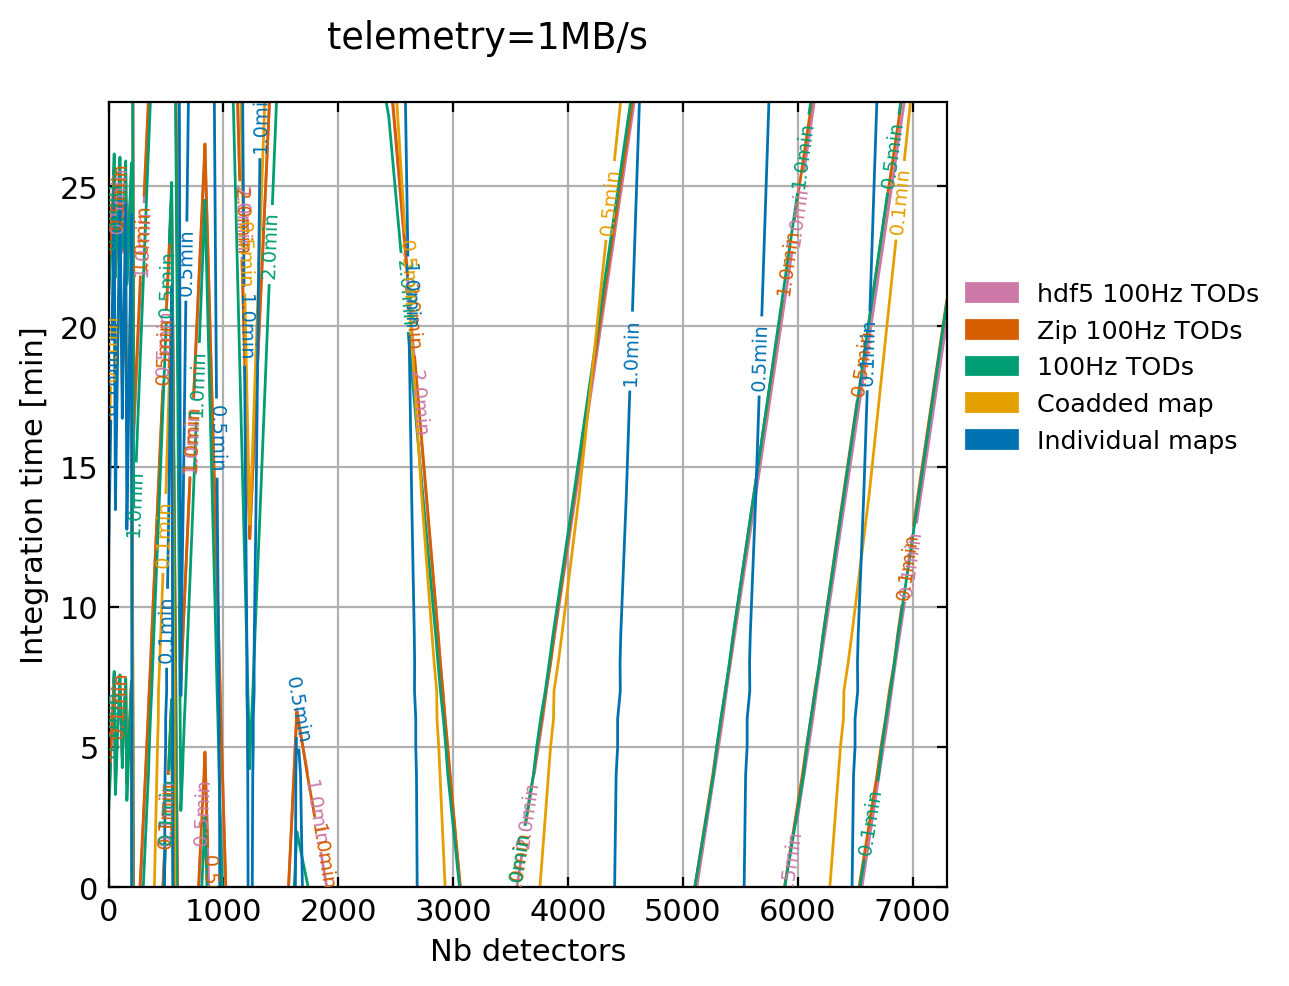

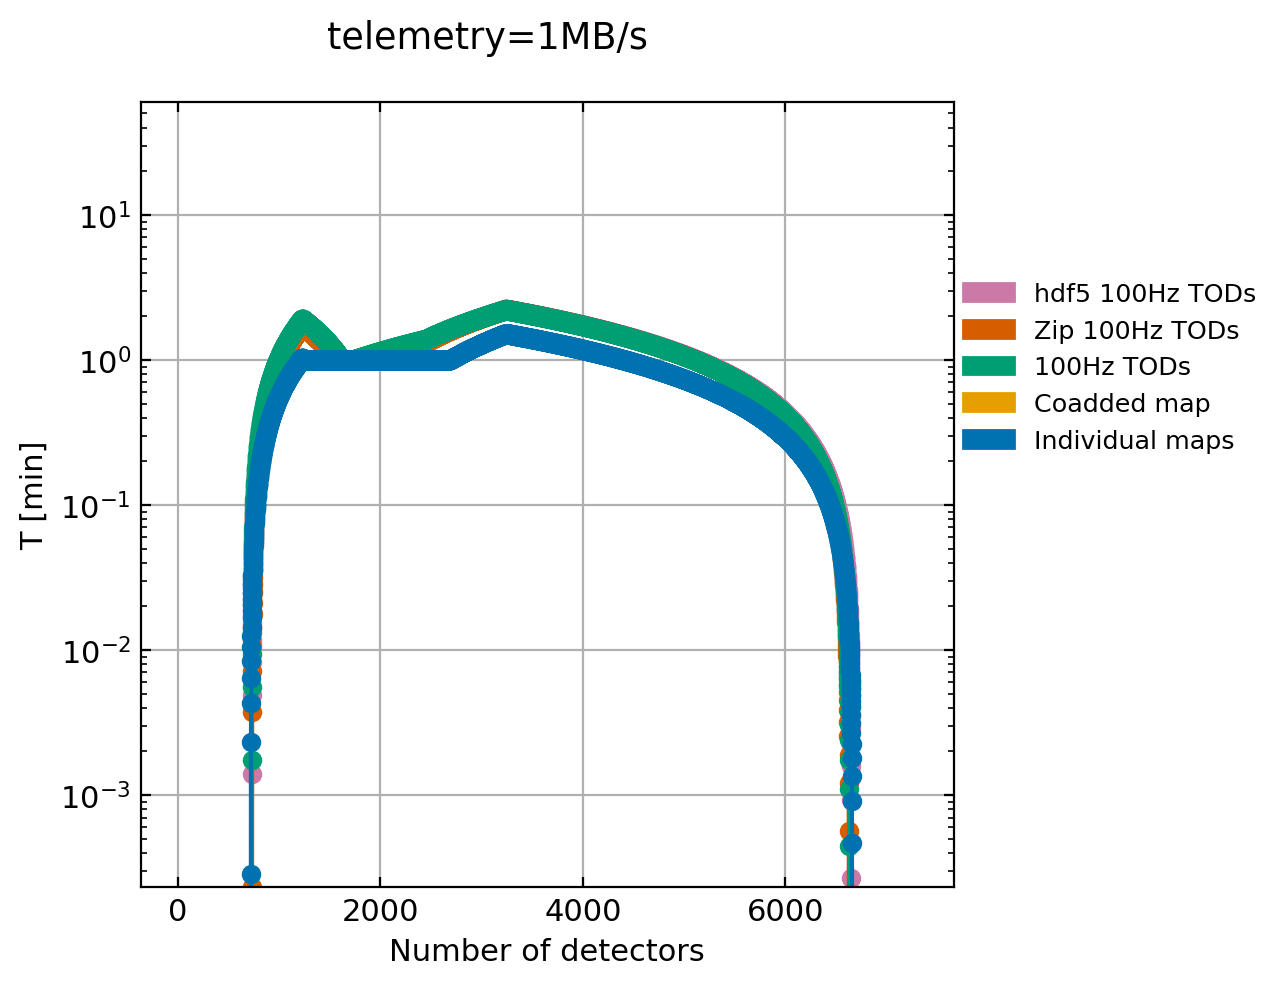

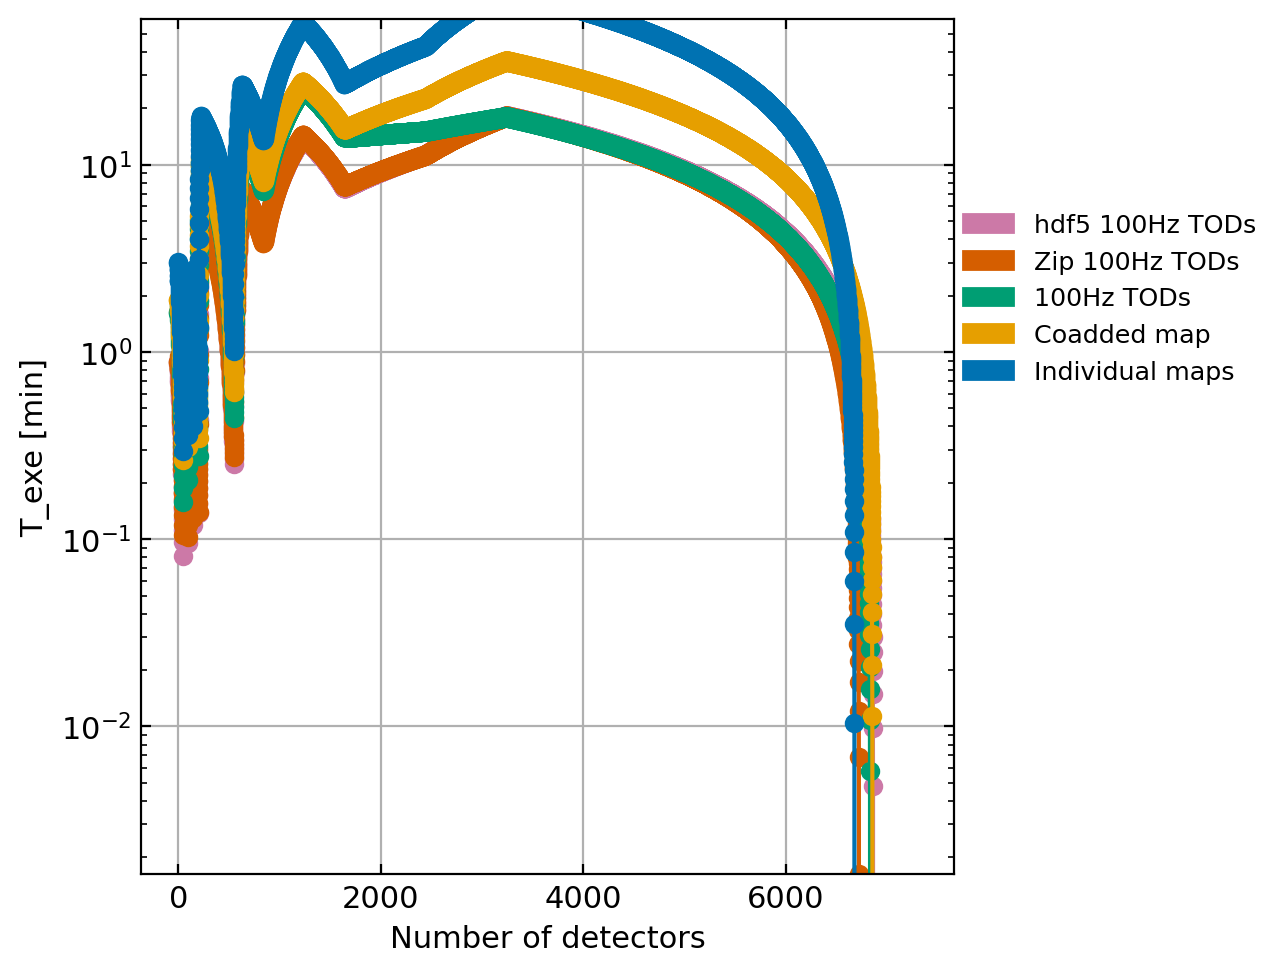

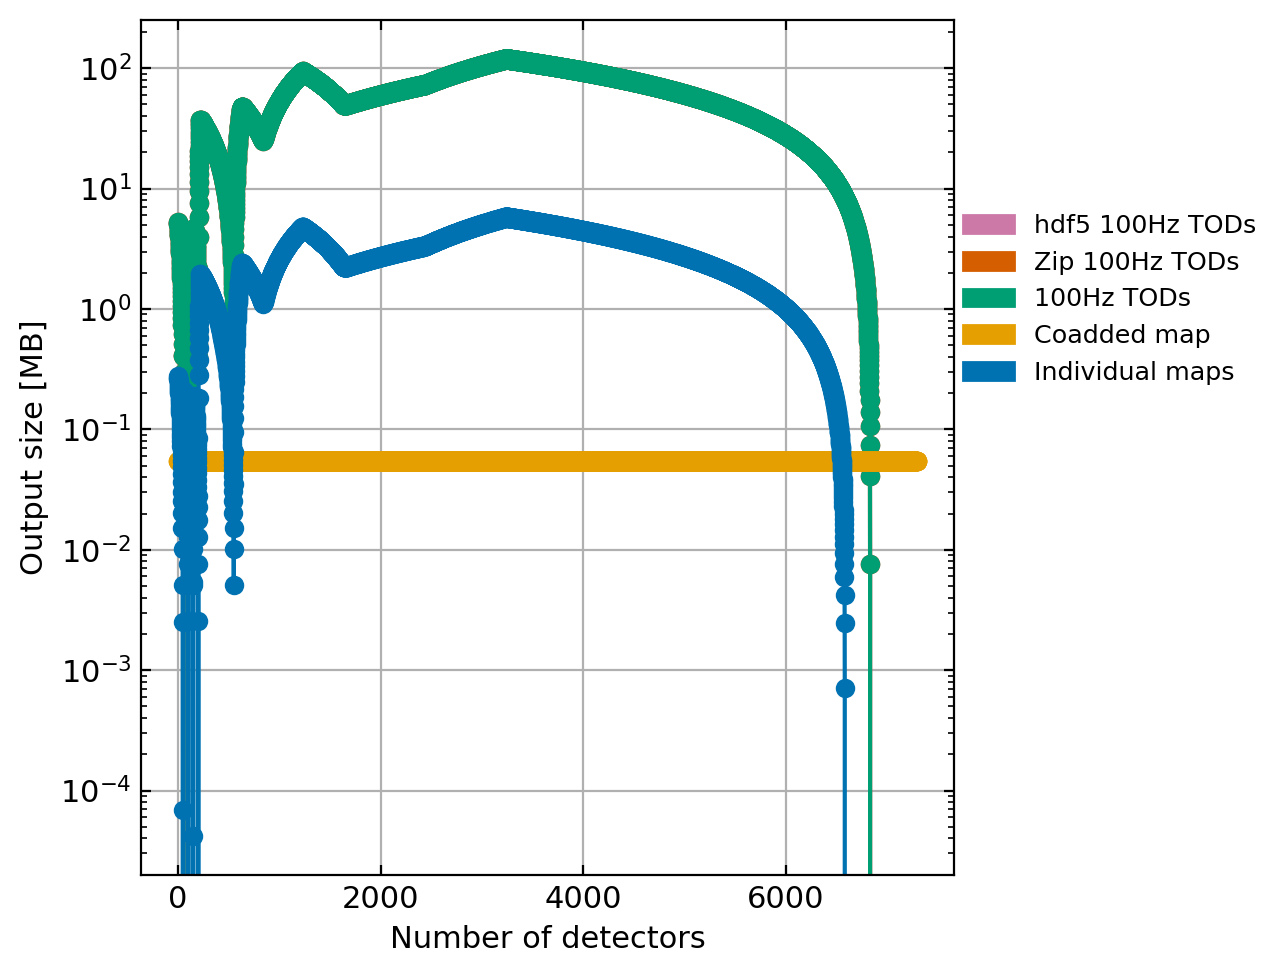

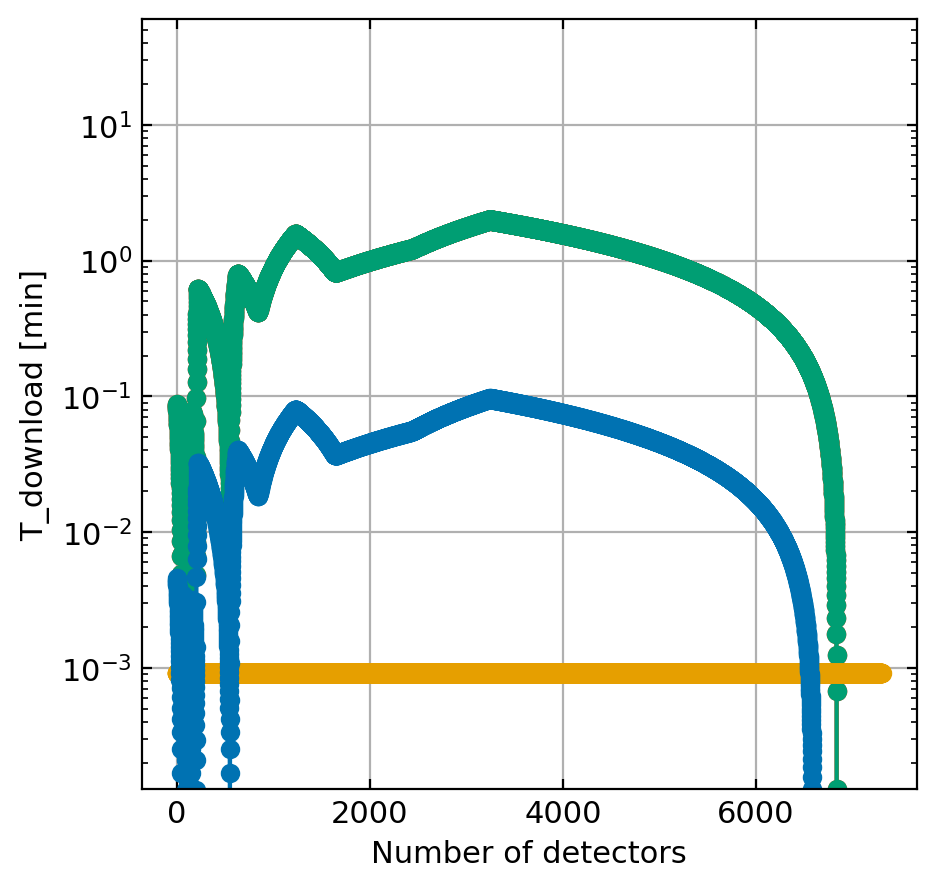

In [11]:
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
]

for t,  (telemetry, marker, label) in enumerate(zip((0.048828125,1 ), ('.','x'), ('1KB/s', '1MB/s'), )):

    FIG, AX = plt.subplots(figsize=(5,5), dpi=200)
    FIG.suptitle(f'telemetry={label}')

    fig, axs = plt.subplots(figsize=(5,5), dpi=200)
    figa, axa = plt.subplots(figsize=(5,5), dpi=200)
    figb, axb = plt.subplots(figsize=(5,5), dpi=200)
    figc, axc = plt.subplots(figsize=(5,5), dpi=200)

    fig.suptitle(f'telemetry={label}')

    patchs = []
    for file, map_compression, ct, label_output in zip(reversed(files), reversed(compressions),reversed(colors), reversed(label_outputs)):

        perfs = pickle.load( open(file, 'rb'))

        norm = cm.colors.Normalize(vmax=1.1, vmin=0)
        cmap = cm.binary
        #cset1 = AX.contourf(perfs['% RAM map'], levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
        #cset2 = AX.contour(perfs['% RAM map'], cset1.levels, colors=ct)
        #cset2.set_linestyle(':')

        levels = (5, 30, 60, 120)

        CS = AX.contour(perfs_params[map_compression]['profiling vs nb bands'][precision][f'model {label} Ttot'],
                        levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
        AX.clabel(CS, inline=True, fmt=lambda v: f"{v/60:.1f}min", fontsize=7, colors=ct)
        AX.set_ylabel("Integration time [min]")
        AX.set_xlabel("Nb detectors")

        patch = mpatches.Patch(color=ct, label=label_output); patchs.append(patch); 
    
        key = f'x Ttot=t, {label}'
        if (map_compression in perfs_params and
            'profiling vs tod time' in perfs_params[map_compression] and
            precision in perfs_params[map_compression]['profiling vs tod time'] and
            key in perfs_params[map_compression]['profiling vs tod time'][precision]):
            d = perfs_params[map_compression]['profiling vs tod time'][precision]
            axs.plot(d[f'x Ttot=t, {label}'], d[f'y Ttot=t, {label}'], '-o', color=ct)            
            #axs.plot(perfs_params[map_compression]['profiling vs tod time'][precision][f'x Ttot=t, {label}'], perfs_params[map_compression]['profiling vs tod time'][precision][f'y Ttot=t, {label}'], color=ct)
        axs.set_ylim(0,60)
        axs.set_ylabel('T [min]')
        axs.set_xlabel('Number of detectors')
        axs.set_yscale('log')

        Texe_grid = perfs_params[map_compression]['profiling vs nb bands'][precision]['model Texe'] 
        axa.plot(XX[:], Texe_grid[idxT0, :], '-o', color=ct)
        axa.set_ylabel('T_exe [min]')
        axa.set_ylim(0,60)
        axa.set_xlabel('Number of detectors')
        axa.set_yscale('log')

        output_grid = perfs_params[map_compression]['profiling vs nb bands'][precision]['model output'] 
        axb.plot(XX[:], output_grid[idxT0, :], '-o', color=ct)
        axb.set_ylabel('Output size [MB]')
        axb.set_xlabel('Number of detectors')
        axb.set_yscale('log')


        output_grid = perfs_params[map_compression]['profiling vs nb bands'][precision]['model output'] 
        axc.plot(XX[:], output_grid[idxT0, :]/telemetry/60, '-o', color=ct)
        axc.set_ylabel('T_download [min]')
        axc.set_xlabel('Number of detectors')
        axc.set_ylim(0,60)
        axc.set_yscale('log')
   
    
    FIG.tight_layout()
    AX.legend(handles=patchs, bbox_to_anchor = (1.4, 0.8))    
    fig.tight_layout()
    axs.legend(handles=patchs, bbox_to_anchor = (1.4, 0.8))   
    figa.tight_layout() ; axa.legend(handles=patchs, bbox_to_anchor = (1.4, 0.8))    
    figb.tight_layout() ; axb.legend(handles=patchs, bbox_to_anchor = (1.4, 0.8))    